# Laboratorio: la temperatura del suelo y la difusividad térmica — guía del docente

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/docente/lab-suelo.ipynb)

> Versión con las soluciones completas. La versión para estudiantes, con esqueletos en lugar de las soluciones, es `notebooks/lab-suelo.ipynb`.

Este laboratorio cierra el primer problema conductor de la Parte III: la temperatura del suelo. En el texto planteamos el modelo (la ecuación del calor en el semieje $x>0$ con un forzado periódico en la superficie), lo resolvimos (la **solución periódica** $u_{per} = \bar T + A e^{-x/\delta}\cos(\omega t - x/\delta)$ con $\delta = \sqrt{2D/\omega}$) y dijimos qué se lee de ella: atenuación, retraso, profundidad de penetración. Quedaron pendientes las preguntas 4 y 5 del problema: **dadas mediciones a varias profundidades, ¿se puede estimar la difusividad térmica $D$ del suelo? ¿Se puede comprobar que el modelo es correcto? ¿A qué profundidad hay que enterrar una cañería para que no se congele?** Eso es lo que hacemos acá, con un año de datos horarios.

**Qué vamos a hacer.** Mirar los datos y entender *qué son* (Tarea 1); medir la amplitud y la fase de los ciclos diario y anual en cada profundidad, con la DFT y con mínimos cuadrados con frecuencia fija (Tarea 2); ajustar las rectas de $\ln A$ y de la fase contra la profundidad y obtener **cuatro estimaciones de $\delta$ y de $D$** con su incertidumbre, que no van a coincidir (Tarea 3); ver cuánto de esa discrepancia se debe a que cada dato es un **promedio sobre una capa** (Tarea 4); **simular** el problema completo con el esquema explícito que ya programaron en el laboratorio de EDPs y comparar con las capas, mirando dónde falla el modelo (Tarea 5); repetir la estimación con un solo mes de datos para saber qué precisión es razonable (Tarea 6); y responder la pregunta de la cañería, con las incertidumbres a la vista (Tarea 7). La Tarea 8, opcional, compara qué pasa si se usa el aire como borde.

**Lo que las notas no explican y este notebook sí.** La DFT de un registro con huecos o de un tramo que no contiene períodos enteros, y su alternativa (regresión armónica con frecuencia fija); cómo se propagan las incertidumbres de una regresión a $\delta$ y a $D$ (¡que dependen de $1/\text{pendiente}$ y de su cuadrado!); mínimos cuadrados no lineales con parámetros "molestos" que hay que ajustar aunque no interesen; el promedio de una solución sobre una capa; y los detalles de simular un semiespacio con un dominio finito (profundidad, condición inferior, dato inicial, *spin-up*, paso de tiempo). El texto de las secciones 1 a 6 es la única presentación que van a tener de estos temas: léanlo, no solo las consignas.

**Herramientas disponibles.** `imc.datos.obtener` (los datos), `imc.espectro.amplitudes` (la DFT con la convención de las notas), `imc.espectro.filtrar` (Tarea 8), `imc.estilo`, `scipy.optimize.least_squares` (que se explica en el laboratorio del modelo SIR: si no lo hicieron, lean su Sección 2) y `numpy.linalg.lstsq`. No vamos a volver a construir nada del notebook `09-calor`: allí están la solución periódica y una versión resumida del ajuste de $D$; acá hacemos ese ajuste paso a paso, con incertidumbres, y lo confrontamos con una simulación.

**Cómo se evalúa.** Como siempre: la sección final de **interpretación escrita** (las cinco preguntas del problema conductor, ahora con números). Cada tarea dice qué se espera y trae una celda de verificación. Tiempo estimado: una sesión de 4 h para las Tareas 1 a 6; las Tareas 7 y 8 son la continuación (30 y 40 minutos).

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from imc import estilo, datos
from imc.estilo import COLORES
import pandas as pd
from scipy.optimize import least_squares
from imc import espectro
from imc.estilo import CICLO
estilo.activar()

## 1. El modelo, la solución periódica y el dato

### El modelo y su solución periódica

Sea $x \ge 0$ la profundidad y $u(x,t)$ la temperatura del suelo, que suponemos homogéneo con difusividad $D$ (m$^2$/s). Si la temperatura de la superficie es una función conocida $T_s(t)$, el modelo es la ecuación del calor en el semieje:

$$u_t = D\,u_{xx}\ (x>0),\qquad u(0,t) = T_s(t),\qquad u \text{ acotada cuando } x\to\infty .$$

Para un forzado de una sola frecuencia, $T_s = \bar T + A\cos(\omega t + \varphi_s)$, la solución en la que la oscilación tiene la misma frecuencia que el forzado es

$$u_{per}(x,t) = \bar T + A\, e^{-x/\delta}\cos\Bigl(\omega t + \varphi_s - \frac{x}{\delta}\Bigr),\qquad \delta = \sqrt{\frac{2D}{\omega}} .$$

Como la ecuación es lineal, un forzado con varias frecuencias (el ciclo anual, el diario y sus armónicos) da la suma de las soluciones periódicas, **cada una con su propio $\delta_k = \sqrt{2D/\omega_k}$**: las frecuencias altas se apagan más rápido, y por eso la forma de la onda se va redondeando con la profundidad.

**Cómo se lee.** A profundidad $x$, la amplitud es $A(x) = A\,e^{-x/\delta}$ y la fase de la oscilación es $\varphi(x) = \varphi_s - x/\delta$. Conviene trabajar con el **retraso de fase** $\psi(x) = \varphi_s - \varphi(x) = x/\delta$, que crece con la profundidad (el retraso temporal es $\psi/\omega = x/(\delta\omega)$). Las dos funciones que vamos a medir son entonces *rectas en $x$*:

$$\ln A(x) = \ln A(0) - \frac{x}{\delta},\qquad \psi(x) = \psi(0) + \frac{x}{\delta}\quad(\text{con }\psi(0)=0\text{ si se mide respecto de la superficie}).$$

(El texto escribe que $\varphi(x)$ tiene pendiente $1/\delta$; con la convención $\cos(\omega t + \varphi)$ de la Parte II la pendiente de $\varphi$ es $-1/\delta$, y la de $\psi = -\varphi$ es $+1/\delta$. Acá usamos $\psi$.)

**Los números que hay que tener en la cabeza** (con el valor típico $D = 5\times10^{-7}$ m$^2$/s): $\delta_{\text{diario}} = \sqrt{2D/\omega_d} \approx 12$ cm y $\delta_{\text{anual}} \approx 2.2$ m; el cociente es $\sqrt{365} \approx 19$. A profundidad $\delta$ la amplitud es el 37 % de la de la superficie y el retraso es $1/\omega$: unas 4 horas para el ciclo diario y unos 2 meses para el anual.

### El dato: qué es y qué no es

El archivo `suelo_horaria.csv` (ver `datos/README.md`) tiene el año 2023 completo, cada hora (8760 filas, sin huecos, hora local), en un punto de Buenos Aires (Aeroparque): la temperatura del aire (`t_aire`) y la de cuatro capas de suelo, $0$–$7$, $7$–$28$, $28$–$100$ y $100$–$255$ cm.

**Advertencia de modelado, y es parte de la lección.** El enunciado del ejercicio habla de "registros de temperatura a varias profundidades". Estos datos no son eso: son de un **reanálisis** (ERA5-Land: un modelo de superficie terrestre que asimila observaciones) y cada columna es la temperatura **promedio de una capa** de espesor entre $7$ y $155$ cm, no la de un sensor enterrado a una profundidad dada. Tres consecuencias que van a aparecer una y otra vez:

1. Hay que asignarle a cada capa una **profundidad representativa**. Usamos el punto medio: $x = 3.5,\ 17.5,\ 64$ y $177.5$ cm. Es una aproximación; en la Tarea 4 vemos cuándo es buena y cuándo no.
2. El dato *es la salida de un modelo* de suelo, con sus propias hipótesis (suelo estratificado, humedad variable, un forzado atmosférico completo). Que nuestro modelo simple ajuste o no ajuste dice algo sobre la *consistencia* de los dos modelos, no sobre un suelo real. Con sensores enterrados a $5$, $10$, $20$, $50$ y $100$ cm el tratamiento sería el mismo, pero los promedios de capa desaparecerían.
3. No tenemos la temperatura en $x=0$. La capa superficial ($0$–$7$ cm) es lo más cercano: no es el aire (ver Sección 5) ni la superficie misma.

También hay que recordar que estamos en el hemisferio sur: enero es verano y julio es invierno.

In [2]:
capas = ["t_suelo_0_7", "t_suelo_7_28", "t_suelo_28_100", "t_suelo_100_255"]
nombres = ["0–7 cm", "7–28 cm", "28–100 cm", "100–255 cm"]
bordes = np.array([0.0, 0.07, 0.28, 1.00, 2.55])        # límites de las capas (m)
x_m = 0.5 * (bordes[:-1] + bordes[1:])                  # profundidad representativa: punto medio (m)
omega_d = 2 * np.pi / 86400                             # ciclo diario (rad/s)
omega_a = 2 * np.pi / (365 * 86400)                     # ciclo anual (rad/s)
D_tipico = 5e-7                                         # m^2/s
delta_de = lambda D, omega: np.sqrt(2 * D / omega)      # profundidad de penetración
D_de = lambda delta, omega: delta ** 2 * omega / 2      # difusividad a partir de delta
print("profundidades representativas (m):", x_m)
print(f"con D = {D_tipico:.0e}:  delta diario = {100 * delta_de(D_tipico, omega_d):.1f} cm,  delta anual = {delta_de(D_tipico, omega_a):.2f} m")

profundidades representativas (m): [0.035 0.175 0.64  1.775]
con D = 5e-07:  delta diario = 11.7 cm,  delta anual = 2.24 m


### Tarea 1: Cargar, graficar y describir

Cargá los datos con `pd.read_csv(datos.obtener("suelo_horaria.csv"), parse_dates=["fecha_hora"])` y construí: `N` (cantidad de filas), `t` (tiempo en **segundos** desde la primera fila, array de largo `N`), `aire` (array de la temperatura del aire) e `Y` (array `(N, 4)` con las cuatro capas, en el orden de `capas`). Las cantidades físicas están en unidades SI (metros, segundos): así $D$ sale en m$^2$/s.

Después:

1. Verificá que no hay huecos (que el paso es siempre de una hora) y armá una tabla con la media, el desvío, el mínimo y el máximo del aire y de cada capa.
2. Graficá, en una figura de cuatro paneles: **(a)** una semana de enero (del 9 al 16) hora por hora, con el aire y las cuatro capas; **(b)** una semana de julio (del 10 al 17); **(c)** el año completo en medias diarias; **(d)** el **ciclo diario medio**: la temperatura media a cada hora del día (0 a 23) para cada serie.
3. De (d) sacá, para cada serie, la hora del día en que ocurre el máximo del ciclo medio y la amplitud pico a pico (máximo menos mínimo).

**Qué se espera.** En (a) el ciclo diario se atenúa y se retrasa capa a capa (a $28$–$100$ cm ya casi no se ve); en (b) es mucho más chico que en (a): la amplitud diaria depende de la estación. En (c) el ciclo anual también se atenúa y se retrasa, pero mucho menos. En (d) el máximo de la capa superficial ocurre alrededor de las 15 h (como el del aire, pero con más amplitud) y el de la capa $7$–$28$ cm cuatro horas después; en las capas más profundas el ciclo medio es de centésimas de grado y la "hora del máximo" no significa nada. Anotá qué observás sobre la capa superficial respecto del aire (¿oscila más o menos? ¿por qué podría ser?): es lo que hace que el aire no sea un buen borde (Sección 5).

paso de tiempo único (s): [3600.] ; N = 8760 ; hay NaN: False
             mean   std   min   max
aire        18.24  6.32  -0.2  37.0
0–7 cm      19.26  7.24   1.2  40.1
7–28 cm     19.11  5.79   5.7  31.8
28–100 cm   19.14  4.66  11.4  28.1
100–255 cm  19.32  3.61  14.3  25.2

ciclo diario medio:
             hora del máximo  pico a pico (°C)
aire                     15              6.19
0–7 cm                   15              8.70
7–28 cm                  19              1.96
28–100 cm                 2              0.06
100–255 cm               10              0.01


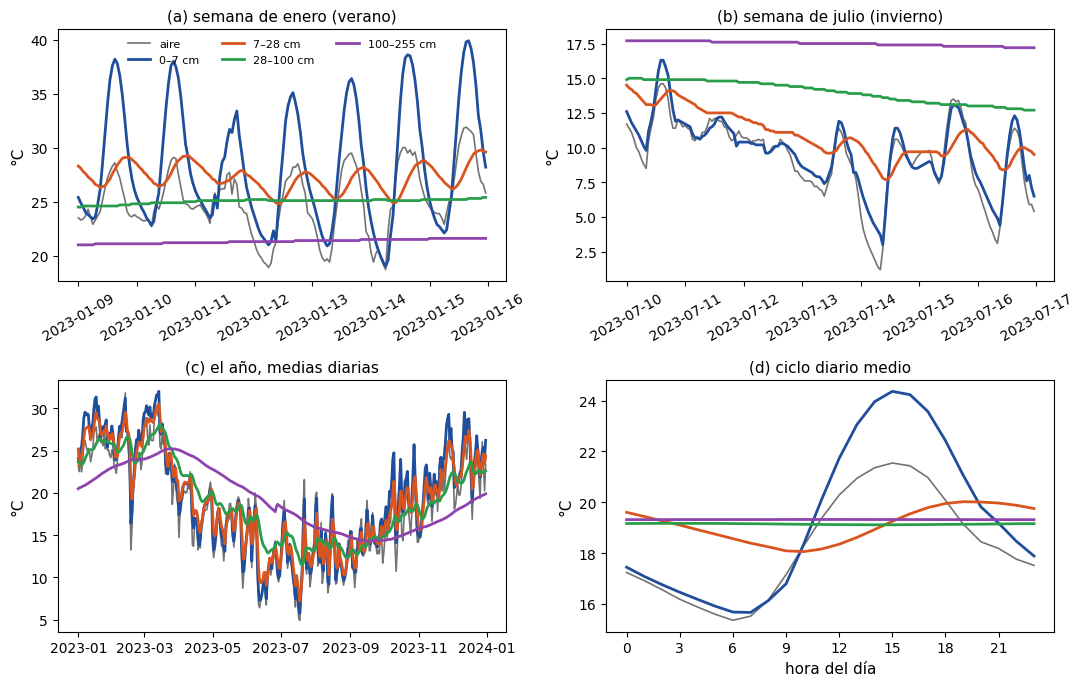

In [3]:
suelo = pd.read_csv(datos.obtener("suelo_horaria.csv"), parse_dates=["fecha_hora"])
N = len(suelo)
t = (suelo.fecha_hora - suelo.fecha_hora.iloc[0]).dt.total_seconds().values
aire = suelo["t_aire"].values
Y = suelo[capas].values

print("paso de tiempo único (s):", np.unique(np.diff(t)), "; N =", N, "; hay NaN:", bool(suelo.isna().any().any()))
todas = ["t_aire"] + capas
etiq = ["aire"] + nombres
print(suelo[todas].agg(["mean", "std", "min", "max"]).round(2).set_axis(etiq, axis=1).T)

hora = suelo.fecha_hora.dt.hour
ciclo_medio = suelo.groupby(hora)[todas].mean()
resumen = pd.DataFrame({"hora del máximo": ciclo_medio.idxmax().values,
                        "pico a pico (°C)": (ciclo_medio.max() - ciclo_medio.min()).round(2).values}, index=etiq)
print("\nciclo diario medio:\n", resumen)

col = ["0.45"] + CICLO[:4]
diaria = suelo.set_index("fecha_hora")[todas].resample("D").mean()
fig, axs = plt.subplots(2, 2, figsize=(11, 7))
for ax, (a, b), titulo in [(axs[0, 0], ("2023-01-09", "2023-01-16"), "(a) semana de enero (verano)"),
                           (axs[0, 1], ("2023-07-10", "2023-07-17"), "(b) semana de julio (invierno)")]:
    sel = (suelo.fecha_hora >= a) & (suelo.fecha_hora < b)
    for c, e, k in zip(todas, etiq, col):
        ax.plot(suelo.fecha_hora[sel], suelo[c][sel], color=k, lw=1.2 if c == "t_aire" else 2, label=e)
    ax.set_title(titulo); ax.set_ylabel("°C"); ax.tick_params(axis="x", labelrotation=30)
axs[0, 0].legend(ncol=3, fontsize=8, loc="upper center")
for c, e, k in zip(todas, etiq, col):
    axs[1, 0].plot(diaria.index, diaria[c], color=k, lw=1.2 if c == "t_aire" else 2, label=e)
    axs[1, 1].plot(ciclo_medio.index, ciclo_medio[c], color=k, lw=1.2 if c == "t_aire" else 2, label=e)
axs[1, 0].set_title("(c) el año, medias diarias"); axs[1, 0].set_ylabel("°C")
axs[1, 1].set_title("(d) ciclo diario medio"); axs[1, 1].set_xlabel("hora del día"); axs[1, 1].set_ylabel("°C"); axs[1, 1].set_xticks(range(0, 24, 3))
fig.tight_layout()

In [4]:
# Verificación
assert N == 8760 and Y.shape == (8760, 4) and aire.shape == (8760,) and t.shape == (8760,)
assert np.allclose(np.diff(t), 3600) and not np.isnan(Y).any(), "el paso debe ser de 3600 s y no debe haber NaN"
assert 18 < Y.mean() < 20 and Y[:, 0].std() > Y[:, 3].std(), "la capa superficial oscila más que la profunda"
print("datos: OK")

datos: OK


**Para el docente.** Medias: aire $18.2$ °C, capas $19.3$, $19.1$, $19.1$, $19.3$ °C (el aire es $1$ °C más frío que el suelo: radiación). Ciclo diario medio: el máximo del aire y de la capa superficial es a las 15 h (pico a pico $6.2$ y $8.7$ °C: la capa superficial oscila un $40\,\%$ más que el aire), el de $7$–$28$ cm a las 19 h ($2.0$ °C de pico a pico); en $28$–$100$ y $100$–$255$ cm el ciclo medio es de $0.06$ y $0.01$ °C. Errores típicos: armar `t` en horas o en días (entonces $D$ sale con un factor $3600^2$ o $86400^2$ de error en toda la guía; que lo detecten en la Tarea 3 al comparar con $5\times10^{-7}$); no parsear las fechas. Tiempo: 20 minutos.

## 2. Amplitud y fase de los ciclos diario y anual

### Con la DFT

Un año tiene $N = 8760$ muestras horarias, es decir $T = 8760$ h $= 365$ días exactos. La DFT (Parte II) da las frecuencias $\xi_k = k/T$: el **ciclo anual** es exactamente $k = 1$ y el **ciclo diario** es $k = 365$ (24 h $= T/365$). Es la razón por la que estos datos son cómodos: contienen un número *entero* de períodos de cada ciclo, y entonces no hay pérdida espectral (*leakage*). Con la convención de las notas, la componente $k$ de la serie $x_n$ es $A_k\cos(2\pi k n/N + \varphi_k)$ con

$$A_k = \frac{2|X_k|}{N},\qquad \varphi_k = \arg X_k,\qquad X_k = \sum_{n=0}^{N-1} x_n\,e^{-2\pi i kn/N}\quad(0<k<N/2).$$

La fase se mide con el origen de tiempos en la primera fila (el 1/1 a las 00:00): es un origen común a todas las series, y eso es lo único que importa, porque de la fase solo usamos **diferencias entre profundidades**. `imc.espectro.amplitudes(x, dt)` devuelve `(xi, A, phi)` con esta convención.

### Con mínimos cuadrados y frecuencia fija

La alternativa es plantear la **regresión armónica**: ajustar a los datos $x(t_n)$ el modelo

$$x(t) \approx c_0 + \sum_{j} \bigl[a_j\cos(\omega_j t) + b_j\sin(\omega_j t)\bigr]$$

con las frecuencias $\omega_j$ *fijas* (las que nos interesan). El modelo es lineal en $c_0, a_j, b_j$, así que es la regresión múltiple de Estadística: se arma la matriz de diseño $M$ (una columna de unos, y un par coseno/seno por frecuencia), se resuelve `np.linalg.lstsq(M, x)` y la amplitud y la fase salen de $a_j\cos\omega t + b_j\sin\omega t = A_j\cos(\omega t + \varphi_j)$, es decir

$$A_j = \sqrt{a_j^2 + b_j^2},\qquad \varphi_j = \operatorname{atan2}(-b_j,\ a_j).$$

**Para qué sirve si ya tenemos la DFT.** En un año completo y sin huecos, las columnas de $M$ son **ortogonales** (los senos y cosenos de períodos enteros lo son) y la solución de mínimos cuadrados coincide *exactamente* con la DFT: en esta parte del laboratorio dan lo mismo hasta el redondeo. La regresión es más robusta cuando la DFT no se puede usar bien:

* **Con huecos.** La DFT necesita muestras uniformes: hay que rellenar los huecos (con ceros, con la media, interpolando) y todo relleno le quita señal al ciclo (si falta el 20 % de las horas y las rellenás con la media, la amplitud del ciclo diario se subestima en un 20 %). La regresión usa solo las filas que existen.
* **Con tramos cortos o que no contienen períodos enteros**, como un mes de datos (Tarea 6). Se pueden agregar a $M$ **columnas de tendencia** (un polinomio de grado bajo en el tiempo) para que la variación lenta, como el ciclo anual visto en un mes, no contamine el ciclo diario, y **armónicos** ($2\omega_j$) para que la forma no sinusoidal de la onda tampoco lo haga.
* **Cuando se quiere la incertidumbre** de $a_j, b_j$: la regresión da la matriz de covarianza $\hat\sigma^2(M^\top M)^{-1}$.

**Qué se espera de la Tarea 2.** Que las dos tablas (DFT y mínimos cuadrados) coincidan hasta $10^{-9}$; y que con el registro con huecos que armamos, la DFT con interpolación subestime la amplitud diaria (del orden del 15–20 %, la fracción de horas que faltan) y la regresión no (error de unos pocos por ciento).

In [5]:
# Un registro con huecos: borramos el 19 % de las horas en tramos de 6 a 48 horas y una semana entera (semilla fija)
rng = np.random.default_rng(2023)
mask = np.ones(N, bool)
for _ in range(60):
    i0 = rng.integers(0, N - 48)
    mask[i0:i0 + rng.integers(6, 48)] = False
mask[3000:3168] = False
print(f"horas que faltan: {100 * (1 - mask.mean()):.1f} %")

horas que faltan: 19.4 %


### Tarea 2: Amplitud y fase de cada ciclo, por dos métodos

Escribí:

* `dft_ciclo(y, k)`: devuelve `(A, phi)` del armónico `k` de la serie `y`, con la convención de arriba.
* `ls_ciclos(y, t, omegas, grado=0)`: regresión armónica por mínimos cuadrados con las frecuencias `omegas` (rad/s) fijas; la matriz de diseño lleva una columna por cada potencia $\tilde t^j$, $j = 0, \dots,$ `grado` (con $\tilde t$ el tiempo normalizado a $[-1/2, 1/2]$), y un par $\cos(\omega t)$, $\sin(\omega t)$ por frecuencia. Devuelve una lista de pares `(A, phi)`, uno por frecuencia.

**(a)** Armá el DataFrame `tab_dft` (filas: aire y las cuatro capas, con `nombres_s = ["aire"] + nombres`; columnas `A_anual`, `phi_anual`, `A_diaria`, `phi_diaria`) con la DFT ($k = 1$ y $k = 365$), y `tab_ls` con lo mismo por mínimos cuadrados (con `omegas = [omega_a, omega_d]`). Imprimí la tabla y la diferencia máxima entre las dos.

**(b)** *El registro con huecos.* La celda de arriba de esta tarea arma una máscara `mask` que borra el 19 % de las horas en tramos de 6 a 48 horas (y una semana entera). Para las capas superficiales ($0$–$7$ y $7$–$28$ cm) estimá el **ciclo diario** de tres maneras: (i) la referencia del año completo (`tab_dft`); (ii) DFT del registro con los huecos rellenados por interpolación lineal (`np.interp`); (iii) mínimos cuadrados usando solo las filas con `mask` (agregá los armónicos $2\omega_a$ y $2\omega_d$ para reducir la contaminación). Mostrá el error relativo de la amplitud y el error de la fase de (ii) y (iii).

**Qué se espera.** (a): diferencias del orden de $10^{-12}$. Valores de referencia para chequear: la amplitud anual del aire es de unos $7$ °C y la de la capa superficial de unos $8$ °C; la amplitud diaria de la capa superficial es de unos $4$ °C y baja a menos de $1$ °C en $7$–$28$ cm y a $0.03$ °C en $28$–$100$ cm. (b): la DFT con interpolación pierde entre el 15 y el 20 % de amplitud; mínimos cuadrados, unos pocos por ciento (o menos).

In [6]:
def dft_ciclo(y, k):
    """Amplitud y fase del armónico k de la serie y (convención A cos(2 pi k n/N + phi))."""
    X = np.fft.rfft(y)[k]
    return 2 * np.abs(X) / len(y), np.angle(X)

def ls_ciclos(y, t, omegas, grado=0):
    """Regresión armónica con frecuencias fijas. Devuelve [(A_1, phi_1), (A_2, phi_2), ...]."""
    tn = (t - t.mean()) / (t.max() - t.min())            # tiempo normalizado a [-1/2, 1/2]
    cols = [tn ** j for j in range(grado + 1)]            # tendencia (grado 0: la media)
    for w in omegas:
        cols += [np.cos(w * t), np.sin(w * t)]
    coef = np.linalg.lstsq(np.column_stack(cols), y, rcond=None)[0]
    salida = []
    for i in range(len(omegas)):
        a, b = coef[grado + 1 + 2 * i], coef[grado + 2 + 2 * i]
        salida.append((np.hypot(a, b), np.arctan2(-b, a)))
    return salida

series = [aire] + [Y[:, i] for i in range(4)]
nombres_s = ["aire"] + nombres
columnas = ["A_anual", "phi_anual", "A_diaria", "phi_diaria"]
tab_dft = pd.DataFrame([[*dft_ciclo(y, 1), *dft_ciclo(y, 365)] for y in series], index=nombres_s, columns=columnas)
filas_ls = []
for y in series:
    (Aa, pa), (Ad, pd_) = ls_ciclos(y, t, [omega_a, omega_d])
    filas_ls.append([Aa, pa, Ad, pd_])
tab_ls = pd.DataFrame(filas_ls, index=nombres_s, columns=columnas)
print(tab_dft.round(4).to_string())
print(f"\ndiferencia máxima DFT - mínimos cuadrados: {np.abs(tab_dft.values - tab_ls.values).max():.1e}")
xi, A_esp, phi_esp = espectro.amplitudes(aire, dt=3600)
print(f"imc.espectro.amplitudes (aire): A[1] = {A_esp[1]:.4f}, A[365] = {A_esp[365]:.4f}")

# (b) registro con huecos
ref = {i: tab_dft.iloc[1 + i][["A_diaria", "phi_diaria"]].values for i in range(2)}
filas_b = []
for i in range(2):
    y = Y[:, i]
    A_i, p_i = dft_ciclo(np.interp(t, t[mask], y[mask]), 365)
    A_l, p_l = ls_ciclos(y[mask], t[mask], [omega_a, 2 * omega_a, omega_d, 2 * omega_d])[2]     # el tercero es omega_d
    A0, p0 = ref[i]
    filas_b.append([nombres[i], A0, 100 * (A_i / A0 - 1), p_i - p0, 100 * (A_l / A0 - 1), p_l - p0])
print(f"\nhoras que faltan: {100 * (1 - mask.mean()):.1f} %")
print(pd.DataFrame(filas_b, columns=["capa", "A ref (°C)", "DFT interp: error A (%)", "DFT interp: error fase (rad)",
                                     "LS: error A (%)", "LS: error fase (rad)"]).round(3).to_string(index=False))

            A_anual  phi_anual  A_diaria  phi_diaria
aire         6.9156    -0.4188    2.7575      2.1639
0–7 cm       7.9642    -0.3492    4.0342      2.1138
7–28 cm      7.4760    -0.4367    0.9343      0.8486
28–100 cm    6.4108    -0.6802    0.0279     -0.6712
100–255 cm   5.0801    -1.3353    0.0029     -2.9758

diferencia máxima DFT - mínimos cuadrados: 2.7e-13
imc.espectro.amplitudes (aire): A[1] = 6.9156, A[365] = 2.7575

horas que faltan: 19.4 %
   capa  A ref (°C)  DFT interp: error A (%)  DFT interp: error fase (rad)  LS: error A (%)  LS: error fase (rad)
 0–7 cm       4.034                  -18.299                         0.002            1.612                 0.007
7–28 cm       0.934                  -18.695                         0.005            0.075                 0.030


In [7]:
# Verificación
assert np.abs(tab_dft.values - tab_ls.values).max() < 1e-8, "DFT y mínimos cuadrados deberían coincidir en un año completo"
assert abs(tab_dft.loc["aire", "A_anual"] - 6.9) < 0.3 and abs(tab_dft.loc["0–7 cm", "A_diaria"] - 4.0) < 0.2
assert tab_dft.loc["28–100 cm", "A_diaria"] < 0.05
assert abs(dft_ciclo(3 * np.cos(2 * np.pi * 5 * np.arange(100) / 100 + 0.7), 5)[0] - 3) < 1e-9, "dft_ciclo: A = 2|X_k|/N"
print("amplitud y fase: OK")

amplitud y fase: OK


**Para el docente.** Las dos tablas coinciden hasta $3\times10^{-13}$ (año completo, sin huecos: ortogonalidad). Valores: aire $A_1 = 6.92$, $A_{365} = 2.76$ °C; capa $0$–$7$: $7.96$ y $4.03$; $7$–$28$: $7.48$ y $0.934$; $28$–$100$: $6.41$ y $0.0279$; $100$–$255$: $5.08$ y $0.0029$ °C. Con el $19.4\,\%$ de horas faltantes: DFT con interpolación, error de amplitud diaria $-18.3\,\%$ ($0$–$7$) y $-18.7\,\%$ ($7$–$28$), casi sin error de fase; mínimos cuadrados con máscara (más $2\omega_a$, $2\omega_d$), $+1.6\,\%$ y $+0.08\,\%$ (fase: $0.007$ y $0.03$ rad). El punto para la discusión: la DFT pierde una fracción de amplitud igual a la de datos que faltan (el relleno agrega señal nula), la regresión no. Errores típicos: el signo de la fase en la regresión (`arctan2(-b, a)`, porque $a\cos + b\sin = A\cos(\omega t + \varphi)$ con $b = -A\sin\varphi$); indexar `rfft` con $k = 365$ (no con $1/24$); olvidar normalizar el tiempo de la tendencia (mal condicionamiento si `grado` es grande). Tiempo: 25 minutos.

## 3. Las rectas de $\ln A$ y de $\psi$ contra $x$: cuatro estimaciones de $\delta$

### Qué se ajusta

Con $A_k$ y $\varphi_k$ de cada capa, el modelo predice dos rectas en $x$ con la *misma* pendiente en valor absoluto:

$$\ln A(x) = \ln A(0) - \frac{x}{\delta},\qquad \psi(x) = \psi(0) + \frac{x}{\delta}.$$

De cada recta sale un $\delta = 1/|\text{pendiente}|$, y de $\delta$ sale $D = \delta^2\omega/2$: **dos estimaciones por ciclo, cuatro en total** (amplitud y fase, diario y anual). Como $\omega_d$ y $\omega_a$ son conocidos, la incertidumbre de $D$ viene solo de la de la pendiente.

**La fase, con cuidado.** La fase de cada capa es un ángulo: está definida módulo $2\pi$. Para que $\psi(x)$ sea una función creíble de $x$ hay que **desenrollarla**: como el retraso entre capas consecutivas es menor que $\pi$, alcanza con sumar a cada diferencia $\varphi_{i+1} - \varphi_i$ el múltiplo de $2\pi$ que la deja en $(-\pi, \pi]$ y acumular. Como no tenemos la superficie, medimos el retraso respecto de la primera capa, $\psi_i - \psi_1$; la ordenada al origen de la recta absorbe lo que falta.

**Qué capas usar.** Para el ciclo anual, las cuatro. Para el diario, las dos superficiales: en la tercera ($28$–$100$ cm) la amplitud diaria es de $0.03$ °C, la señal es apenas más grande que el error de cuantización de los datos (cada dato tiene un decimal), y su "retraso" es dudoso (la capa mide $72$ cm, seis veces $\delta_{\text{diario}}$: Tarea 4). Con dos puntos la recta pasa exacta y no hay grados de libertad para estimar una incertidumbre; para ese caso proponemos otro camino (más abajo).

### Incertidumbre de la regresión, y su propagación

De Estadística: para $n$ puntos $(x_i, y_i)$ y la recta $y = a + bx$ por mínimos cuadrados, con residuos $e_i$,

$$\hat\sigma^2 = \frac{\sum e_i^2}{n-2},\qquad \operatorname{se}(b) = \frac{\hat\sigma}{\sqrt{S_{xx}}},\quad S_{xx} = \sum (x_i - \bar x)^2,\qquad \operatorname{se}(a) = \hat\sigma\sqrt{\frac1n + \frac{\bar x^2}{S_{xx}}} .$$

Con $n = 4$ hay solo **2 grados de libertad**: el intervalo de confianza del 95 % usa el cuantil $t_{2,\,0.975} = 4.3$, no $1.96$. Y $\delta$ y $D$ *no son lineales* en la pendiente: $\delta = 1/|b|$, $D = \delta^2\omega/2 = \omega/(2b^2)$. Con la aproximación de primer orden (delta method),

$$\operatorname{se}(\delta) \approx \frac{\operatorname{se}(b)}{b^2},\qquad \frac{\operatorname{se}(D)}{D} \approx \frac{2\operatorname{se}(b)}{|b|} = \frac{2\operatorname{se}(\delta)}{\delta} .$$

Una pendiente con 10 % de error relativo da un $D$ con 20 %. Además, si la pendiente es chica respecto de su error, $\delta$ y $D$ explotan.

**Para el ciclo diario: remuestreo de días.** Hay una incertidumbre que la regresión de dos puntos no ve, pero que se puede medir: cuánto cambiaría la amplitud y la fase del ciclo diario de cada capa si tuviéramos *otros* días. Para eso calculamos la amplitud compleja $C_d = \frac{2}{24}\sum_h y_{d,h}\,e^{-i\omega_d t_h}$ **de cada día** $d$ (el promedio de los 365 $C_d$ es exactamente la DFT con $k=365$) y hacemos un **bootstrap por bloques**: se sortean con reposición bloques de 10 días consecutivos (los días vecinos se parecen, así que remuestrear días sueltos subestimaría la variabilidad), se promedian los $C_d$ elegidos, se calculan $A$ y $\varphi$ de las dos capas y de ahí el $\delta$ y el $D$; con 1000 remuestreos, el desvío de esos $D$ es una medida de la incertidumbre. No es una incertidumbre "de regresión" sino de *muestreo temporal*: es la que refleja que enero y julio no son iguales.

**Qué se espera.** Las cuatro estimaciones de $D$ están entre $3\times10^{-7}$ y $2\times10^{-6}$ m$^2$/s: el ciclo diario da valores del orden de $3$–$5\times10^{-7}$ (por amplitud y por fase, parecidos entre sí y al valor típico); el anual da por fase un valor de unos $3\times10^{-7}$ y por amplitud un valor **cinco veces mayor**. Las incertidumbres estadísticas que calcules van a ser chicas (de unos pocos por ciento, salvo la del anual por amplitud, cerca del $20\,\%$): **las diferencias entre las estimaciones son mucho mayores que sus incertidumbres**. Eso es lo que distingue un error de medición (que la incertidumbre describe) de un *error de modelo* (que no describe): si las cuatro estimaciones fueran del mismo $D$, tendrían que coincidir dentro de sus incertidumbres, y no lo hacen. Que dos estimaciones del mismo ciclo difieran por un factor 5 no es un error de programación: es el hallazgo del laboratorio. La pregunta 3 del enunciado ("¿coinciden? ¿deberían?") se responde con esta tarea y con la siguiente.

### Tarea 3: Rectas, cuatro estimaciones de $\delta$ y $D$, incertidumbres

Escribí:

* `recta(x, y)`: ajuste $y = a + bx$; devuelve `(a, b, se_a, se_b)` con los errores estándar de arriba (`np.nan` si hay solo dos puntos).
* `retraso_de_fase(phi)`: desenrolla las fases de capas consecutivas y devuelve $\psi_i - \psi_1$ (creciente con la profundidad).
* `estimar(x, y, omega, tipo)`: con `tipo="amp"` (y = $\ln A$, pendiente $-1/\delta$) o `tipo="fase"` (y = $\psi$, pendiente $+1/\delta$), devuelve `(delta, se_delta, D, se_D)` propagando la incertidumbre como arriba.

Con eso llená el diccionario `est` con las cuatro estimaciones: claves `("anual", "amp")`, `("anual", "fase")`, `("diario", "amp")`, `("diario", "fase")` (anual con las cuatro capas, diario con las dos superficiales). Para el ciclo diario, calculá la incertidumbre con el **bootstrap por bloques** descripto arriba (`Cd`: array `(365, 4)` de amplitudes complejas por día) y guardala en `se_D`.

Imprimí una tabla con $\delta$, $D$ y sus incertidumbres, y graficá, para cada ciclo, en un mismo panel y contra $x$: la **atenuación** $-(\ln A - \ln A_1)$ y el **retraso** $\psi - \psi_1$, con sus dos rectas ajustadas. Si el modelo valiera, las dos curvas coincidirían.

Como extra, calculá el $D$ diario con las *tres* capas superficiales (regresión de tres puntos, con su error estándar) y comentá qué le pasa a la estimación por fase.

**Qué se espera.** Un gráfico (dos paneles, ciclo anual y ciclo diario) en el que atenuación y retraso son casi rectas pero con pendientes distintas: en el anual, la atenuación es mucho más lenta que el retraso. Valores de $D$ (orden de magnitud): diario por amplitud y por fase entre $3$ y $5\times10^{-7}$; anual por fase $\approx 3\times10^{-7}$, por amplitud $\approx 1.6\times10^{-6}$. Incertidumbres estadísticas chicas (unos pocos por ciento, salvo la del anual por amplitud, cerca del $20\,\%$): las diferencias entre las estimaciones son mucho mayores que ellas.

             delta (m)  se delta  D (m²/s)     se D
anual  amp        3.99     0.401  1.58e-06 3.18e-07
       fase       1.77    0.0228  3.12e-07 8.03e-09
diario amp      0.0957       NaN  3.33e-07 1.26e-08
       fase      0.111       NaN  4.45e-07  1.3e-08

D típico = 5e-07;  D (diario amp, fase) = 3.33e-07, 4.45e-07;  D (anual amp, fase) = 1.58e-06, 3.12e-07
diario, 3 capas, por amp: delta = 12.4 cm, D = 5.60e-07 ± 7.5e-08
diario, 3 capas, por fase: delta = 23.4 cm, D = 2.00e-06 ± 1.0e-06


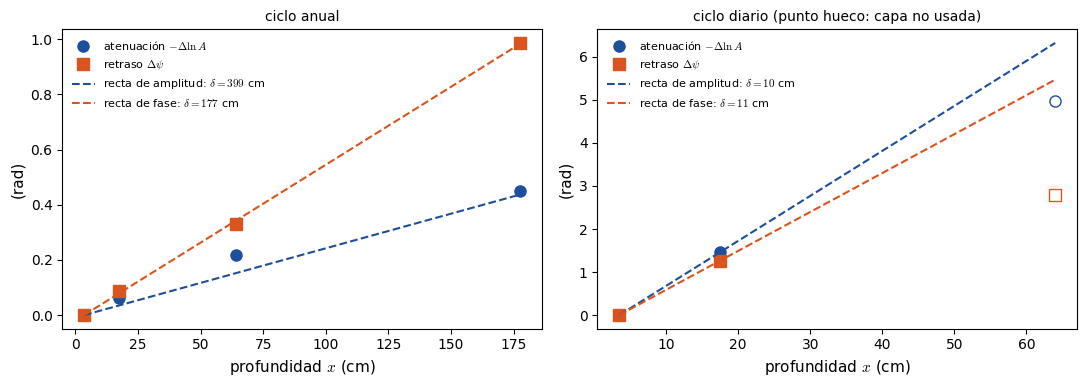

In [8]:
def recta(x, y):
    """Ajuste y = a + b x. Devuelve (a, b, se_a, se_b)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    n = len(x)
    b, a = np.polyfit(x, y, 1)
    if n <= 2:
        return a, b, np.nan, np.nan
    e = y - (a + b * x)
    s2 = e @ e / (n - 2)
    Sxx = np.sum((x - x.mean()) ** 2)
    return a, b, np.sqrt(s2 * (1 / n + x.mean() ** 2 / Sxx)), np.sqrt(s2 / Sxx)

def retraso_de_fase(phi):
    """Retraso de fase respecto de la primera capa, desenrollando las diferencias entre capas consecutivas."""
    d = np.diff(phi)
    d = (d + np.pi) % (2 * np.pi) - np.pi          # cada diferencia en (-pi, pi]
    return -np.concatenate([[0.0], np.cumsum(d)])

def estimar(x, y, omega, tipo):
    """tipo = "amp" (y = ln A, pendiente -1/delta) o "fase" (y = psi, pendiente +1/delta). Devuelve (delta, se_delta, D, se_D)."""
    a, b, se_a, se_b = recta(x, y)
    signo = -1 if tipo == "amp" else 1
    delta = 1 / (signo * b)
    D = D_de(delta, omega)
    return delta, se_b / b ** 2, D, 2 * D * se_b / abs(b)

# amplitudes complejas por día y por capa (365 x 4): Cd[d, i] = (2/24) sum_h y[d, h, i] exp(-i omega_d t_h)
E = np.exp(-1j * omega_d * np.arange(24) * 3600)
Cd = (2 / 24) * (Y.reshape(365, 24, 4) * E[None, :, None]).sum(axis=1)
assert np.allclose(np.abs(Cd.mean(axis=0)), tab_dft.A_diaria.values[1:]), "el promedio de los C_d es la DFT con k = 365"

est = {}
A_a, P_a = tab_dft.A_anual.values[1:], tab_dft.phi_anual.values[1:]
A_d, P_d = tab_dft.A_diaria.values[1:], tab_dft.phi_diaria.values[1:]
psi_a, psi_d = retraso_de_fase(P_a), retraso_de_fase(P_d)
est[("anual", "amp")] = estimar(x_m, np.log(A_a), omega_a, "amp")
est[("anual", "fase")] = estimar(x_m, psi_a, omega_a, "fase")

def D_diario_de(C, capas_usadas=(0, 1)):
    """(D por amplitud, D por fase) del ciclo diario a partir de amplitudes complejas C (una por capa), con dos capas."""
    i, j = capas_usadas
    A, P = np.abs(C), np.angle(C)
    dA = (x_m[j] - x_m[i]) / np.log(A[i] / A[j])
    dP = (x_m[j] - x_m[i]) / retraso_de_fase(P[[i, j]])[1]
    return D_de(dA, omega_d), D_de(dP, omega_d)

rng = np.random.default_rng(1)
boot = []
for _ in range(1000):
    inicios = rng.integers(0, 365, 37)                              # 37 bloques de 10 días
    dias = (inicios[:, None] + np.arange(10)).ravel() % 365
    boot.append(D_diario_de(Cd[dias].mean(axis=0)))
boot = np.array(boot)
D_dA, D_dP = D_diario_de(Cd.mean(axis=0))
est[("diario", "amp")] = (delta_de(D_dA, omega_d), np.nan, D_dA, boot[:, 0].std())
est[("diario", "fase")] = (delta_de(D_dP, omega_d), np.nan, D_dP, boot[:, 1].std())

tabla = pd.DataFrame({k: v for k, v in est.items()}, index=["delta (m)", "se delta", "D (m²/s)", "se D"]).T
print(tabla.to_string(float_format=lambda v: f"{v:.3g}"))
print(f"\nD típico = {D_tipico:.0e};  D (diario amp, fase) = {D_dA:.2e}, {D_dP:.2e};  D (anual amp, fase) = {est[('anual', 'amp')][2]:.2e}, {est[('anual', 'fase')][2]:.2e}")

# extra: ciclo diario con tres capas
for nombre, y, tipo in [("amp", np.log(A_d[:3]), "amp"), ("fase", psi_d[:3], "fase")]:
    dl, sdl, Dd, sDd = estimar(x_m[:3], y, omega_d, tipo)
    print(f"diario, 3 capas, por {nombre}: delta = {100 * dl:.1f} cm, D = {Dd:.2e} ± {sDd:.1e}")

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, ciclo, usadas, mostradas, A, psi in [(axs[0], "anual", 4, 4, A_a, psi_a), (axs[1], "diario", 2, 3, A_d, psi_d)]:
    aten = -(np.log(A) - np.log(A[0]))
    for i in range(mostradas):
        rell = dict(mfc="white") if i >= usadas else {}
        ax.plot(100 * x_m[i], aten[i], "o", ms=8, color=COLORES["dato"], **rell, label=r"atenuación $-\Delta\ln A$" if i == 0 else None)
        ax.plot(100 * x_m[i], psi[i], "s", ms=8, color=COLORES["modelo"], **rell, label=r"retraso $\Delta\psi$" if i == 0 else None)
    xg = np.linspace(x_m[0], x_m[mostradas - 1], 50)
    for tipo, c in [("amp", COLORES["dato"]), ("fase", COLORES["modelo"])]:
        delta_e = est[(ciclo, tipo)][0]
        ax.plot(100 * xg, (xg - x_m[0]) / delta_e, "--", color=c, lw=1.5, label=rf"recta de {'amplitud' if tipo == 'amp' else 'fase'}: $\delta = {100 * delta_e:.0f}$ cm")
    ax.set_title(f"ciclo {ciclo}" + (" (punto hueco: capa no usada)" if ciclo == "diario" else ""), fontsize=10)
    ax.set_xlabel("profundidad $x$ (cm)"); ax.set_ylabel("(rad)"); ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()

In [9]:
# Verificación
D_ad, D_fd = est[("diario", "amp")][2], est[("diario", "fase")][2]
D_aa, D_fa = est[("anual", "amp")][2], est[("anual", "fase")][2]
assert 2.5e-7 < D_ad < 4.5e-7, f"diario por amplitud {D_ad:.2e}: se esperaba ~3.3e-7"
assert 3.5e-7 < D_fd < 5.5e-7, f"diario por fase {D_fd:.2e}: se esperaba ~4.5e-7"
assert 2.5e-7 < D_fa < 3.8e-7, f"anual por fase {D_fa:.2e}: se esperaba ~3.1e-7"
assert 1.2e-6 < D_aa < 2.2e-6, f"anual por amplitud {D_aa:.2e}: se esperaba ~1.6e-6"
assert np.all(np.diff(retraso_de_fase(tab_dft.phi_anual.values[1:])) > 0), "el retraso debe crecer con la profundidad"
print("cuatro estimaciones de D: OK")

cuatro estimaciones de D: OK


**Para el docente.** Resultados: anual por amplitud $\delta = 3.99 \pm 0.40$ m, $D = (1.58 \pm 0.32)\times10^{-6}$; anual por fase $\delta = 1.77 \pm 0.02$ m, $D = (3.12 \pm 0.08)\times10^{-7}$; diario por amplitud $\delta = 9.6$ cm, $D = (3.33 \pm 0.13)\times10^{-7}$; diario por fase $\delta = 11.1$ cm, $D = (4.45 \pm 0.13)\times10^{-7}$ (las dos últimas incertidumbres son del bootstrap por bloques). Con tres capas el diario da $5.6\times10^{-7}$ por amplitud y $2.0\times10^{-6}$ por fase: la tercera capa no sirve como punto (Tarea 4). Lo que hay que subrayar: las incertidumbres estadísticas son de $2$–$20\,\%$ y las estimaciones difieren en un factor $5$ (anual) o $1.3$ (diario): es un error de modelo, no de medición. Errores típicos: tomar el retraso como $\varphi_1 - \varphi_i$ sin cuidar el módulo $2\pi$ (con estos datos solo importa para la capa $100$–$255$ cm del ciclo diario, que no se usa; pero es el error clásico); tomar `-1/b` con la pendiente de la fase (signo); usar `polyfit` y olvidar los errores estándar; propagar mal a $D$ (olvidar el cuadrado: $\text{se}(D)/D = 2\,\text{se}(b)/|b|$). Con cuatro puntos y $2$ grados de libertad, el error estándar de la pendiente anual por fase ($1.3\,\%$) es engañosamente chico: conviene mencionar $t_{2,0.975} = 4.3$. Tiempo: 40 minutos.

## 4. Cada dato es un promedio de capa: qué corrige y qué no

### El promedio de la solución periódica

Lo que mide (o mejor: lo que informa) el dato $k$ no es $u(x_k, t)$ sino el promedio sobre la capa $[a, b]$ de espesor $h = b - a$:

$$\bar u_{[a,b]}(t) = \frac1h\int_a^b u(x,t)\,dx .$$

Escribamos la solución periódica con notación compleja, $u_{per} = \bar T + \operatorname{Re}\bigl[\,A e^{i\varphi_s}\,e^{i\omega t}\,e^{-zx}\bigr]$ con $z = (1+i)/\delta$. Como el promedio es lineal y $e^{i\omega t}$ no depende de $x$,

$$\bar u_{[a,b]}(t) = \bar T + \operatorname{Re}\bigl[\,A e^{i\varphi_s}\; g(\delta; a, b)\; e^{i\omega t}\bigr],\qquad g(\delta; a, b) = \frac1h\int_a^b e^{-zx}\,dx = \frac{e^{-za} - e^{-zb}}{z\,h}.$$

La capa se comporta entonces como un punto con **amplitud** $A|g|$ y **fase** $\varphi_s + \arg g$: el promedio cambia la amplitud por el factor $|g|$ y adelanta o atrasa la fase en $\arg g$, con $g$ una función *conocida* de $\delta$. Para un punto a profundidad $x$ sería $g = e^{-zx}$. Escribiendo $e^{-za} - e^{-zb} = 2e^{-zx_m}\sinh(zh/2)$ con $x_m = (a+b)/2$, queda

$$g(\delta; a, b) = e^{-z x_m}\;\frac{\sinh w}{w},\qquad w = \frac{zh}{2} = (1+i)\frac{h}{2\delta}:$$

**la capa es el punto medio multiplicado por la corrección $\sinh w/w$**, que solo depende de $h/\delta$. Para una capa fina ($h \ll \delta$), $\sinh w/w \approx 1 + w^2/6 = 1 + i\,h^2/(12\delta^2)$: el módulo cambia en $O((h/\delta)^4)$ y la fase en $h^2/(12\delta^2)$, es decir, el promedio está *un poco menos retrasado* que el punto medio. Para una capa gruesa ($h \gtrsim \delta$), $\sinh w/w$ crece como $e^{h/2\delta}$: el promedio queda dominado por el borde *superior* de la capa, donde la oscilación es más grande.

**Atención con la intuición.** Es tentador pensar que "promediar una capa gruesa reduce la amplitud" (mezcla partes con fase distinta). Es al revés: la amplitud de la capa es **mayor** que la del punto medio (porque $e^{-x/\delta}$ es convexa, el promedio en una capa pesa más lo de arriba) y el retraso es **menor**. Y el efecto solo importa cuando $h$ es comparable con $\delta$ del ciclo considerado: enorme para el ciclo diario en la capa $28$–$100$ cm ($h = 72$ cm $\approx 6\delta_d$), y despreciable para el ciclo anual en todas las capas ($h_{max} = 1.55$ m $< \delta_a = 2.2$ m). La Tarea 4 pide calcular esos factores.

### Ajuste con la fórmula integrada

Con el promedio como modelo, ya no hay dos rectas separadas sino **un modelo con tres parámetros** que explica a la vez las amplitudes y las fases de todas las capas de un ciclo. Sea $C_k = A_k e^{i\varphi_k}$ la amplitud compleja medida en la capa $k$. El modelo es

$$C_k \approx C_s\,g(\delta; a_k, b_k),\qquad C_s = e^{\ln A_0}\,e^{-i\psi_0}$$

con parámetros $p = (\ln A_0, \psi_0, \delta)$: la amplitud $A_0$ y la fase $-\psi_0$ **del forzado en $x = 0$** (no las conocemos: la capa superficial es ella misma un promedio) y la profundidad de penetración $\delta$. Los residuos son adimensionales: $\ln|C_k| - \ln|C_s g_k|$ (error relativo de la amplitud) y $\arg(C_k/(C_s g_k))$ (error de fase, en $(-\pi,\pi]$), y se minimiza la suma de cuadrados de todos ellos con `least_squares`.

**Lo que hay que entender de este ajuste** (los mínimos cuadrados no lineales se explican en la Sección 2 del laboratorio SIR; acá van solo las novedades):

* **Parámetros molestos.** $A_0$ y $\psi_0$ no interesan pero hay que ajustarlos: sin ellos, tendríamos que suponer que la superficie tiene la amplitud y la fase de la capa $0$–$7$ cm. Parametrizamos con $\ln A_0$ para que la amplitud sea positiva sin cotas.
* **Amplitud y fase a la vez.** Las dos rectas de la Tarea 3 daban $\delta$ distintos; este ajuste da **un** $\delta$, un compromiso entre las dos informaciones. No es "mejor": si el modelo no es correcto, el compromiso es solo una manera de promediar dos estimaciones inconsistentes, y los residuos (que hay que mirar) lo delatan.
* **Grados de libertad.** Cada capa aporta dos datos (amplitud y fase). Con 4 capas hay 8 datos y 3 parámetros (5 grados de libertad); con las 2 superficiales del ciclo diario, 4 datos y 3 parámetros: **1 solo grado de libertad**, casi identificable. La covarianza de la estimación es la de las notas del SIR, $\hat\sigma^2(J^\top J)^{-1}$ con $\hat\sigma^2 = \mathrm{RSS}/(n-3)$; con un solo grado de libertad la incertidumbre es orientativa.
* **Valores iniciales.** El $\delta$ inicial puede estar a un orden de magnitud del verdadero (¡el ciclo diario y el anual difieren por 19!), y la función de costo tiene mínimos locales. Usá varios arranques con $\delta_0$ repartidos en escala logarítmica (`np.geomspace(0.03, 5, 8)`) y quedate con el de menor costo. Cotas: $\delta \in [0.01, 20]$ m.
* **La fase módulo $2\pi$** en los residuos: `np.angle(C / modelo)` ya devuelve un ángulo en $(-\pi, \pi]$, no hace falta desenrollar.

**Qué se espera.** (i) Los factores de corrección $|g|/|e^{-zx_m}|$ y $\arg g - \arg e^{-zx_m}$ para las cuatro capas y los dos ciclos, con $\delta$ de $D = 5\times10^{-7}$: casi $1$ y casi $0$ para el ciclo anual en todas las capas y para el diario en la capa superficial; en la capa $7$–$28$ cm el ciclo diario tiene un factor $1.01$ pero un adelanto de fase de una hora; y a partir de la tercera capa el factor es de unos $2.5$ con un corrimiento de fase de más de $2$ rad. (ii) Un $D$ anual **entre las dos estimaciones de la Tarea 3** (de un orden de $5$–$6\times10^{-7}$), prácticamente igual con y sin promedio de capa. (iii) Para el ciclo diario con tres capas, el modelo puntual da un ajuste malo y un $D$ absurdo, y el modelo con promedio ajusta con residuos chicos y da un $D$ del orden de $4\times10^{-7}$. Así que el promedio de capas **no explica** la discrepancia del ciclo anual; sí permite usar la tercera capa en el ciclo diario.

### Tarea 4: Corrección por promedio de capa y ajuste no lineal de $\delta$

Escribí:

* `ganancia(delta, a, b)`: la función $g(\delta; a, b)$ de arriba (compleja). Verificala contra la integral numérica (promedio de `np.exp(-(1+1j)*x/delta)` en una grilla fina de $[a,b]$).
* `ajustar_capas(C, idx, omega, modo="capa")`: ajusta $(\ln A_0, \psi_0, \delta)$ a las amplitudes complejas `C[idx]` (las capas de índices `idx`) con `least_squares` y varios arranques; con `modo="punto"` usa $g = e^{-zx_m}$ (profundidad = punto medio) en lugar del promedio. Devuelve un diccionario con `delta`, `se_delta` (de $\hat\sigma^2(J^\top J)^{-1}$; `np.nan` si no hay grados de libertad), `D` (con `omega`), `se_D` (propagando como en la Tarea 3), `A0`, `psi0` y `rss` (suma de cuadrados de los residuos).

Después: **(a)** una tabla de los factores $|g|/|g_{punto}|$ y de $\arg g - \arg g_{punto}$ (en horas o días) para cada capa y cada ciclo (con $\delta$ de $D = 5\times10^{-7}$); **(b)** los ajustes: anual con las 4 capas y diario con 3 y con 2 capas, en los dos modos, con una tabla de $\delta$, $D$ y RSS; **(c)** una figura con tres paneles: la amplitud diaria contra $x$ (datos, y ajuste puntual y de capa evaluados en cada capa), lo mismo para la anual, y el factor $|\sinh w/w|$ contra $h/\delta$ con las capas de los dos ciclos marcadas.

Guardá en `D_capa_a` y `D_capa_d` los $D$ del ajuste con promedio de capa del ciclo anual (4 capas) y del diario (3 capas).

**Qué se espera.** Ver la lista de "qué se espera" de arriba. Para el ciclo anual, $D \approx 6\times10^{-7}$; para el diario con tres capas, $D \approx 4\times10^{-7}$ (con promedio) contra $\approx 10^{-6}$ (puntual). Con dos capas el diario da $\approx 3.8\times10^{-7}$ (puntual) y $\approx 2.9\times10^{-7}$ (de capa): la corrección de la capa $7$–$28$ cm ($h\approx 1.8\,\delta_d$) ya se nota en la fase. En todos los casos, mirá también el error estándar de $D$: es de decenas de por ciento (hay pocos grados de libertad).

delta = 0.117, capa [0.07, 0.28]: fórmula 0.076247-0.214129j, integral 0.076247-0.214129j
delta = 0.117, capa [0.28, 1.0]: fórmula -0.010466+0.000390j, integral -0.010466+0.000390j
delta = 2.2, capa [1.0, 2.55]: fórmula 0.321904-0.309316j, integral 0.321904-0.309316j
 ciclo       capa  h/delta  |g|/|g_punto|  arg g/g_punto (rad)  adelanto (h o días)
diario     0–7 cm    0.597          1.000                0.030                0.113
diario    7–28 cm    1.791          1.014                0.266                1.015
diario  28–100 cm    6.140          2.476                2.284                8.725
diario 100–255 cm   13.218         39.679               -0.460               -1.756
 anual     0–7 cm    0.031          1.000                0.000                0.005
 anual    7–28 cm    0.094          1.000                0.001                0.043
 anual  28–100 cm    0.321          1.000                0.009                0.500
 anual 100–255 cm    0.692          1.000                0.0

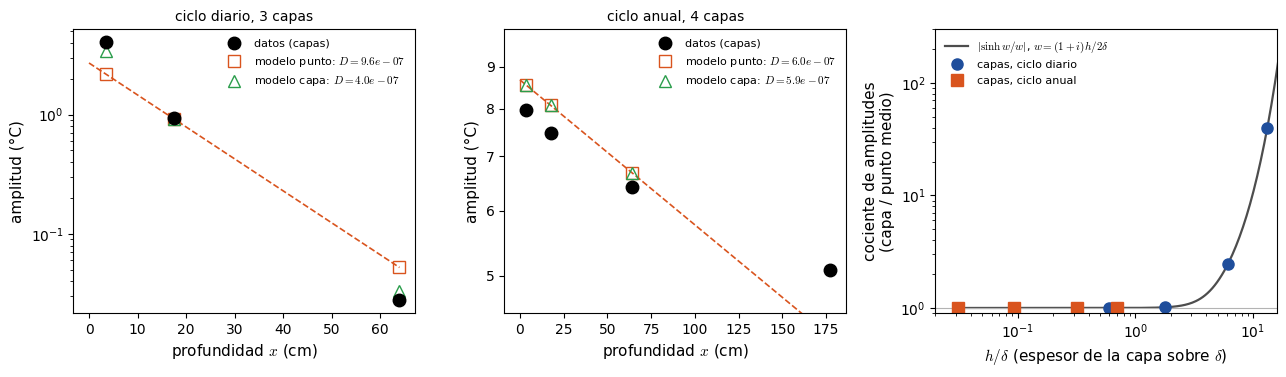

In [10]:
def ganancia(delta, a, b):
    """Promedio sobre [a, b] de exp(-(1+i) x / delta)."""
    z = (1 + 1j) / delta
    return (np.exp(-z * a) - np.exp(-z * b)) / (z * (b - a))

for delta, a, b in [(0.117, 0.07, 0.28), (0.117, 0.28, 1.0), (2.2, 1.0, 2.55)]:
    xs = a + (np.arange(20000) + 0.5) * (b - a) / 20000
    print(f"delta = {delta}, capa [{a}, {b}]: fórmula {ganancia(delta, a, b):.6f}, integral {np.mean(np.exp(-(1 + 1j) * xs / delta)):.6f}")

def ajustar_capas(C, idx, omega, modo="capa"):
    """Ajusta (ln A0, psi0, delta) a las amplitudes complejas C[idx]. Devuelve un dict con
    delta, se_delta, D, se_D, A0, psi0, rss."""
    idx = list(idx)
    Cm = np.asarray(C)[idx]
    def g(delta):
        if modo == "capa":
            return np.array([ganancia(delta, bordes[i], bordes[i + 1]) for i in idx])
        return np.exp(-(1 + 1j) * x_m[idx] / delta)
    def residuos(p):
        modelo = np.exp(p[0] - 1j * p[1]) * g(p[2])
        return np.concatenate([np.log(np.abs(Cm) / np.abs(modelo)), np.angle(Cm / modelo)])
    mejor = None
    for d0 in np.geomspace(0.03, 5, 8):
        r = least_squares(residuos, [np.log(np.abs(Cm[0])), -np.angle(Cm[0]), d0], bounds=([-5, -10, 0.01], [6, 10, 20]))
        if mejor is None or r.cost < mejor.cost:
            mejor = r
    rss, dof = 2 * mejor.cost, len(mejor.fun) - 3
    delta = mejor.x[2]
    se_delta = np.sqrt((rss / dof * np.linalg.inv(mejor.jac.T @ mejor.jac))[2, 2]) if dof > 0 else np.nan
    D = D_de(delta, omega)
    return dict(delta=delta, se_delta=se_delta, D=D, se_D=2 * D * se_delta / delta, A0=np.exp(mejor.x[0]), psi0=mejor.x[1], rss=rss)

C_a = tab_dft.A_anual.values[1:] * np.exp(1j * tab_dft.phi_anual.values[1:])      # amplitudes complejas medidas (4 capas)
C_d = tab_dft.A_diaria.values[1:] * np.exp(1j * tab_dft.phi_diaria.values[1:])

# (a) factores de corrección
filas = []
for ciclo, om, esc, unidad in [("diario", omega_d, 3600, "h"), ("anual", omega_a, 86400, "días")]:
    dl = delta_de(D_tipico, om)
    for i in range(4):
        g_cap = ganancia(dl, bordes[i], bordes[i + 1]); g_pto = np.exp(-(1 + 1j) * x_m[i] / dl)
        filas.append([ciclo, nombres[i], (bordes[i + 1] - bordes[i]) / dl, abs(g_cap) / abs(g_pto), np.angle(g_cap / g_pto), np.angle(g_cap / g_pto) / om / esc])
print(pd.DataFrame(filas, columns=["ciclo", "capa", "h/delta", "|g|/|g_punto|", "arg g/g_punto (rad)", "adelanto (h o días)"]).round(3).to_string(index=False))

# (b) ajustes
fit4 = {}
for ciclo, C, om, ns in [("anual", C_a, omega_a, [4]), ("diario", C_d, omega_d, [3, 2])]:
    for n in ns:
        for modo in ["punto", "capa"]:
            fit4[(ciclo, n, modo)] = ajustar_capas(C, range(n), om, modo)
tabla4 = pd.DataFrame({k: v for k, v in fit4.items()}).T[["delta", "se_delta", "D", "se_D", "A0", "rss"]].astype(float)
print("\n", tabla4.to_string(float_format=lambda v: f"{v:.3g}"))
D_capa_a = fit4[("anual", 4, "capa")]["D"]
D_capa_d = fit4[("diario", 3, "capa")]["D"]
print(f"\nD con promedio de capa: anual {D_capa_a:.2e} (Tarea 3: amplitud {est[('anual', 'amp')][2]:.1e}, fase {est[('anual', 'fase')][2]:.1e});"
      f" diario (3 capas) {D_capa_d:.2e} (Tarea 3, 2 capas: amplitud {est[('diario', 'amp')][2]:.1e}, fase {est[('diario', 'fase')][2]:.1e})")

# (c) figura
fig, axs = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, ciclo, C, om, n in [(axs[0], "diario", C_d, omega_d, 3), (axs[1], "anual", C_a, omega_a, 4)]:
    ax.semilogy(100 * x_m[:n], np.abs(C[:n]), "o", ms=9, color="black", label="datos (capas)", zorder=5)
    for modo, c, mk in [("punto", COLORES["nul_h"], "s"), ("capa", COLORES["nul_p"], "^")]:
        f = fit4[(ciclo, n, modo)]
        if modo == "punto":
            pred = f["A0"] * np.exp(-x_m[:n] / f["delta"])
            xx = np.linspace(0, x_m[n - 1], 100); ax.semilogy(100 * xx, f["A0"] * np.exp(-xx / f["delta"]), "--", color=c, lw=1.2)
        else:
            pred = np.array([f["A0"] * abs(ganancia(f["delta"], bordes[i], bordes[i + 1])) for i in range(n)])
        ax.semilogy(100 * x_m[:n], pred, mk, ms=8, color=c, mfc="none", label=f"modelo {modo}: $D={f['D']:.1e}$")
    ax.set_title(f"ciclo {ciclo}, {n} capas", fontsize=10); ax.set_xlabel("profundidad $x$ (cm)"); ax.set_ylabel("amplitud (°C)"); ax.legend(fontsize=8, loc="upper right")
    if ciclo == "anual":
        ax.set_yticks([5, 6, 7, 8, 9], ["5", "6", "7", "8", "9"]); ax.minorticks_off(); ax.set_ylim(4.5, 10)
hd = np.geomspace(0.03, 30, 300)
w_ = (1 + 1j) * hd / 2
axs[2].loglog(hd, np.abs(np.sinh(w_) / w_), color="0.3", label=r"$|\sinh w/w|$, $w=(1+i)h/2\delta$")
axs[2].axhline(1, color="0.7", lw=0.8)
for ciclo, om, mk in [("diario", omega_d, "o"), ("anual", omega_a, "s")]:
    dl = delta_de(D_tipico, om); hh = np.diff(bordes) / dl
    axs[2].loglog(hh, np.abs(np.sinh((1 + 1j) * hh / 2) / ((1 + 1j) * hh / 2)), mk, ms=8, label=f"capas, ciclo {ciclo}")
axs[2].set_xlim(0.02, 16); axs[2].set_ylim(0.9, 300)
axs[2].set_xlabel(r"$h/\delta$ (espesor de la capa sobre $\delta$)"); axs[2].set_ylabel("cociente de amplitudes\n(capa / punto medio)"); axs[2].legend(fontsize=8, loc="upper left")
fig.tight_layout()

In [11]:
# Verificación
xs = 0.07 + (np.arange(20000) + 0.5) * 0.21 / 20000
assert abs(ganancia(0.117, 0.07, 0.28) - np.mean(np.exp(-(1 + 1j) * xs / 0.117))) < 1e-6, "ganancia: no coincide con la integral numérica"
assert abs(ganancia(1.0, 0.0, 1e-9) - 1) < 1e-6, "una capa de espesor nulo en x = 0 debe dar g = 1"
assert 4e-7 < D_capa_a < 8e-7, f"D anual con promedio de capa {D_capa_a:.2e}: se esperaba ~6e-7"
assert 3e-7 < D_capa_d < 5e-7, f"D diario (3 capas) con promedio de capa {D_capa_d:.2e}: se esperaba ~4e-7"
print("corrección por capas: OK")

corrección por capas: OK


**Para el docente.** Factores de capa (con $D = 5\times10^{-7}$): ciclo diario $|g|/|g_{punto}| = 1.000,\ 1.014,\ 2.48,\ 39.7$ y adelanto de fase $0.03,\ 0.27,\ 2.28,\ -0.46$ rad ($0.1$ h, $1.0$ h, $8.7$ h, ...); ciclo anual $1.000$ en las cuatro capas y adelantos $0.000$, $0.001$, $0.009$, $0.040$ rad ($0.005,\ 0.04,\ 0.5,\ 2.3$ días). Ajustes (RSS y $D$): anual, 4 capas: puntual $D = 5.99\times10^{-7}$ (RSS $0.095$), capa $5.94\times10^{-7}$ (RSS $0.107$), $\delta = 2.44 \pm 0.47$ m, $A_0 = 8.7$ °C; diario, 3 capas: puntual $9.6\times10^{-7}$ (RSS $1.73$), capa $3.96\times10^{-7}$ (RSS $0.249$), $A_0 = 4.8$ °C; diario, 2 capas: puntual $3.83\times10^{-7}$, capa $2.93\times10^{-7}$ (RSS $0.007$; un solo grado de libertad, y $D$ con $\pm 15\,\%$). **Punto que corrige la intuición (y el planteo del ejercicio):** el promedio de capa *no* reduce la amplitud sino que la aumenta, y solo importa cuando $h \gtrsim \delta$: casi nada para el ciclo anual. Por lo tanto **no explica la discrepancia anual** entre amplitud ($1.6\times10^{-6}$) y fase ($3.1\times10^{-7}$); lo que sí hace el ajuste conjunto es dar un compromiso ($5.9\times10^{-7}$, entre ambos, cerca del valor típico) que tiene un RSS no chico: la amplitud pide $\delta = 4$ m y la fase $1.8$ m, y el compromiso deja residuos sistemáticos. Lo que sí explica el promedio: el ciclo diario en la capa $28$–$100$ cm (el RSS baja de $1.73$ a $0.25$). Errores típicos: pensar que el ajuste de capa "arregla" el anual; olvidar los arranques múltiples (con un solo $\delta_0$ el ciclo diario suele quedar en un mínimo local, $\delta \approx 1$ m); ajustar $A_0$ en lugar de $\ln A_0$ sin cotas. Tiempo: 40 minutos (la fórmula de $g$ es lo más largo de entender).

## 5. Simular el problema completo y ver dónde falla

Las estimaciones de las Tareas 3 y 4 usan solo una amplitud y una fase por ciclo. La simulación pone a prueba el modelo con **todo** el registro: toda la señal de la superficie (el ciclo diario y el anual, sus armónicos, las olas de calor, la lluvia...) entra como condición de borde, la ecuación del calor la propaga hacia abajo, y comparamos con lo que dice cada capa. Si el modelo es adecuado, la diferencia es "ruido"; si no, tiene estructura.

### El problema numérico

Un semiespacio no se puede simular: hay que cortarlo. Resolvemos

$$u_t = D\,u_{xx}\ \ (0<x<L,\ t>0),\qquad u(0,t) = T_s(t),\qquad u(L,t) = T_L\ \ (\text{o } u_x(L,t)=0),\qquad u(x,0) = u_0(x),$$

con el **esquema explícito** del Ejercicio de la ecuación del calor (laboratorio de EDPs): con $x_j = j\Delta x$, $t_n = n\Delta t$,

$$u_j^{n+1} = u_j^n + r\,(u_{j+1}^n - 2u_j^n + u_{j-1}^n),\qquad r = \frac{D\,\Delta t}{\Delta x^2},$$

que es estable si y solo si $r \le 1/2$. Decisiones que hay que tomar (y que son parte del modelado, no detalles):

* **Profundidad $L$.** La solución periódica anual decae como $e^{-x/\delta_a}$ con $\delta_a \approx 2.2$ m: a $L = 10$ m queda el 1 % de la amplitud de la superficie. Lo que importa es que el borde inferior no afecte a las capas que comparamos (hasta $2.55$ m): se verifica variando $L$ y la condición inferior. Con $L$ chico, el fondo "ancla" la temperatura y las capas profundas se aplanan.
* **Condición inferior.** $u(L) = T_L$ con $T_L$ la temperatura media anual (a profundidad grande el suelo está a la media), o flujo nulo $u_x(L)=0$ (se implementa copiando el penúltimo nodo). Son la misma idea desde dos lados; a $L$ grande dan lo mismo.
* **Paso espacial.** $\Delta x = 1$ cm: resuelve $\delta_d \approx 12$ cm con más de 10 nodos, y hace que los bordes de las capas ($7$, $28$, $100$, $255$ cm) caigan en nodos. El costo del esquema crece como $1/\Delta x^3$ (nodos $\propto 1/\Delta x$, pasos $\propto 1/\Delta x^2$ por la condición $r\le1/2$): con $L = 10$ m son 1001 nodos.
* **Paso temporal.** El dato es horario, pero con $\Delta x = 1$ cm y $D = 5\times10^{-7}$ estabilidad exige $\Delta t \le \Delta x^2/(2D) = 100$ s. Se hacen entonces $m = \lceil 3600\,D/(r_{max}\Delta x^2)\rceil$ **sub-pasos** por cada hora del dato, con $r_{max} = 0.4$ (un margen), y el borde se interpola linealmente en el tiempo entre dos datos horarios. Ojo: $m$ crece con $D$; si ajustás un $D$ grande y dejás $\Delta t$ fijo, el esquema explota.
* **Dato inicial.** No conocemos el perfil de temperatura del 1/1 (ni por debajo de $2.55$ m): usamos el **perfil medio**, que interpola las medias anuales de las capas en las profundidades $x_m$ y es constante por debajo (todas las capas tienen una media anual de unos $19$ °C).
* **Spin-up.** Un dato inicial incorrecto contamina la solución hasta que se "olvida": el tiempo característico es $x^2/D$ (unas horas a $x=10$ cm, casi una semana a $x=50$ cm, unos tres meses a $x=2$ m). Se corre entonces antes de la fecha de interés un tramo de **calentamiento** (*spin-up*): acá, un mes, repitiendo cíclicamente el forzado (los 31 días anteriores al 1/1 son los últimos 31 de diciembre). La capa más profunda no llega a olvidar del todo el dato inicial en un mes; un spin-up de un año lo prueba (Tarea 5, punto (c)): cambia la capa profunda en unas décimas de grado, mucho menos que los residuos de (b), así que estos no vienen del dato inicial.

### Qué borde usar

**La capa superficial, no el aire.** El modelo pide la temperatura *del suelo* en $x=0$. La temperatura del aire (a 2 m) no es esa: el suelo se calienta por radiación solar y se enfría por radiación infrarroja y evaporación, y la interfaz aire–suelo transfiere calor con un coeficiente finito, no con una igualdad (una condición de Dirichlet con el aire *supone* que el suelo copia al aire). En los datos: la capa $0$–$7$ cm oscila más que el aire (amplitud diaria de unos $4$ °C contra $2.8$ °C; anual de $8$ °C contra $6.9$ °C) y se calienta más en verano. Usar el aire como borde le quita al suelo un tercio de la amplitud diaria antes de empezar (y lo enfría $1$ °C en promedio), y es un error de *modelado* que ningún $D$ compensa (Tarea 8). La capa $0$–$7$ es la observación más cercana a la superficie, y viene del mismo reanálisis que las otras capas: es un forzado *consistente*. Su defecto: es un promedio sobre $7$ cm, no el valor en $x=0$; por eso la capa $0$–$7$ *simulada* (el promedio de la solución sobre $[0,7]$ cm) va a oscilar menos que el dato, aunque el borde sea exactamente el dato (es el efecto de la Tarea 4, al revés). En la Tarea 8 se puede corregir.

### Cómo comparar

Los datos son promedios de capa, así que hay que comparar **promedios de la simulación sobre cada capa** (la solución numérica en cada nodo $\to$ promedio sobre los nodos de $[a,b]$ con la regla del trapecio). Comparar la simulación en $x=x_m$ con el dato sería repetir el error de la Tarea 4. Para cada capa se calculan el **sesgo** (media de $\text{sim}-\text{dato}$) y la **raíz del error cuadrático medio** (RMSE), y se muestran los residuos mes a mes: si son ruido, no dependen del mes; si el modelo omite algo (humedad, lluvia, la estratificación del suelo), el residuo tiene estructura estacional.

**Qué se espera.** Para las capas intermedias ($7$–$28$ y $28$–$100$ cm) un RMSE de unas pocas décimas de grado; para la capa $0$–$7$, del orden de $1$ °C (por el efecto descrito); para la profunda, mayor, del orden de $1$ °C, con sesgo que cambia de signo con la estación.

### Tarea 5: Simulación explícita con la capa superficial como borde

Completá `simular_suelo(D, Ts, L, dx, spin, fondo, T_capas_ini, T_fondo, r_max)`: resuelve el problema con el esquema explícito y devuelve `(capas, x, u_min)`: `capas` es un array `(len(Ts), 4)` con el promedio de la solución sobre cada capa en cada instante del dato (una fila por hora); `x` la grilla; y `u_min` el mínimo, en cada nodo, de la temperatura durante todo el período comparado (lo usa la Tarea 7). Ya está escrita la parte de preparación (grilla, dato inicial, sub-pasos, ciclo de spin-up y el cálculo de los promedios `promedios_capa`); te falta el bucle temporal:

* un sub-paso del esquema explícito en los nodos interiores (con `r`), *in place* y vectorizado;
* el borde izquierdo, interpolando linealmente entre `Ts[i]` y `Ts[i+1]` en cada sub-paso;
* el borde derecho, según `fondo` (`"T"`: Dirichlet $T_L$; `"F"`: flujo nulo).

**(a) Verificación de la implementación.** La celda de verificación (abajo) simula 30 días con un forzado exactamente periódico, $T_s = 20 + 5\cos(\omega_d t)$, y compara cada capa con el promedio de la solución periódica, $20 + \operatorname{Re}[5\,g(\delta; a, b)\,e^{i\omega_d t}]$ (con la $g$ de la Tarea 4): tiene que pasar antes de seguir.

**(b) La simulación del año.** Con `D_sim` (elegilo: la media geométrica de tus dos $D$ de la Tarea 4, o $5\times10^{-7}$) y `Ts = Y[:, 0]` (la capa superficial como borde) simulá 2023 y calculá el sesgo y el RMSE de cada capa. Graficá (i) una semana de enero: datos y simulación en las cuatro capas; (ii) los residuos (sim $-$ dato) de cada capa en medias diarias durante el año; (iii) el RMSE por mes y por capa (mapa de colores).

**(c) Sensibilidad numérica y de modelado.** Repetí (b) con: $L = 5$ m; flujo nulo en $L = 10$ m; spin-up de un año (`spin=365`); $\Delta x = 2$ cm. Mostrá, para cada variante, la diferencia máxima con la corrida base en cada capa. Verificá también que con $L = 2$ m (menos que el fondo de la última capa) el resultado es absurdo: la función tiene que avisar (`assert`) que $L > 2.55$ m.

**(d) Barrido de $D$.** Corré (b) para $D \in \{3, 4, 5, 6, 8\}\times10^{-7}$ y graficá el RMSE de cada capa contra $D$. ¿Qué $D$ minimiza el error en cada capa?

**Qué se espera.** (a) Diferencias de unos centésimos de grado. (b) Ver arriba. (c) Diferencias de menos de $0.15$ °C en las capas de $0$ a $100$ cm en todas las variantes, y de unos $0.3$ °C como máximo en la capa profunda ($L=5$ m y spin-up de un año); el flujo nulo casi no cambia nada. Los errores de (b) no vienen de estas decisiones numéricas: son del modelo. (d) Las capas intermedias y la profunda tienen su mínimo entre $5$ y $6\times10^{-7}$ (la superficial prefiere un $D$ mayor porque su defecto es otro), cerca de tu estimación anual con promedio de capa y sensiblemente mayor que el $D$ de fase del ciclo anual; el mínimo es plano: entre $4$ y $6\times10^{-7}$ el RMSE cambia menos del $20\,\%$. El $D$ que mejor ajusta la *simulación* es el compromiso entre todo lo que el modelo no captura.


D_sim = 4.85e-07 m²/s (media geométrica de las dos estimaciones de la Tarea 4)


            sesgo (°C)  RMSE (°C)  desvío del dato (°C)
0–7 cm            0.00       1.29                  7.24
7–28 cm           0.17       0.42                  5.79
28–100 cm         0.19       0.46                  4.66
100–255 cm        0.13       1.23                  3.61

sesgo por mes (filas: ene-dic; columnas: capas):
 [[-0.18 -0.04 -0.32 -0.07]
 [-0.05 -0.01 -0.29 -0.84]
 [ 0.    0.07 -0.44 -1.33]
 [ 0.14  0.15 -0.04 -1.68]
 [ 0.18  0.2  -0.04 -1.19]
 [ 0.2   0.25  0.37 -0.4 ]
 [ 0.09  0.2   0.32 -0.17]
 [ 0.08  0.26  0.49  0.92]
 [-0.01  0.18  0.66  1.55]
 [-0.11  0.44  0.77  1.9 ]
 [-0.21  0.21  0.53  1.63]
 [-0.09  0.12  0.2   1.11]]



(c) diferencia máxima con la corrida base (°C):
                       0–7 cm  7–28 cm  28–100 cm  100–255 cm
L = 5 m                 0.006    0.031      0.115       0.321
flujo nulo (L = 10 m)   0.000    0.001      0.005       0.016
spin-up de un año       0.005    0.026      0.096       0.269
dx = 2 cm               0.052    0.023      0.001       0.000



(d) RMSE (°C) por capa según D:
       0–7 cm  7–28 cm  28–100 cm  100–255 cm
3e-07    1.55     0.69       0.76        1.52
4e-07    1.39     0.51       0.54        1.30
5e-07    1.27     0.42       0.46        1.23
6e-07    1.18     0.41       0.48        1.24
8e-07    1.05     0.51       0.63        1.37
D que minimiza el RMSE en cada capa: ['8e-07', '6e-07', '5e-07', '5e-07']


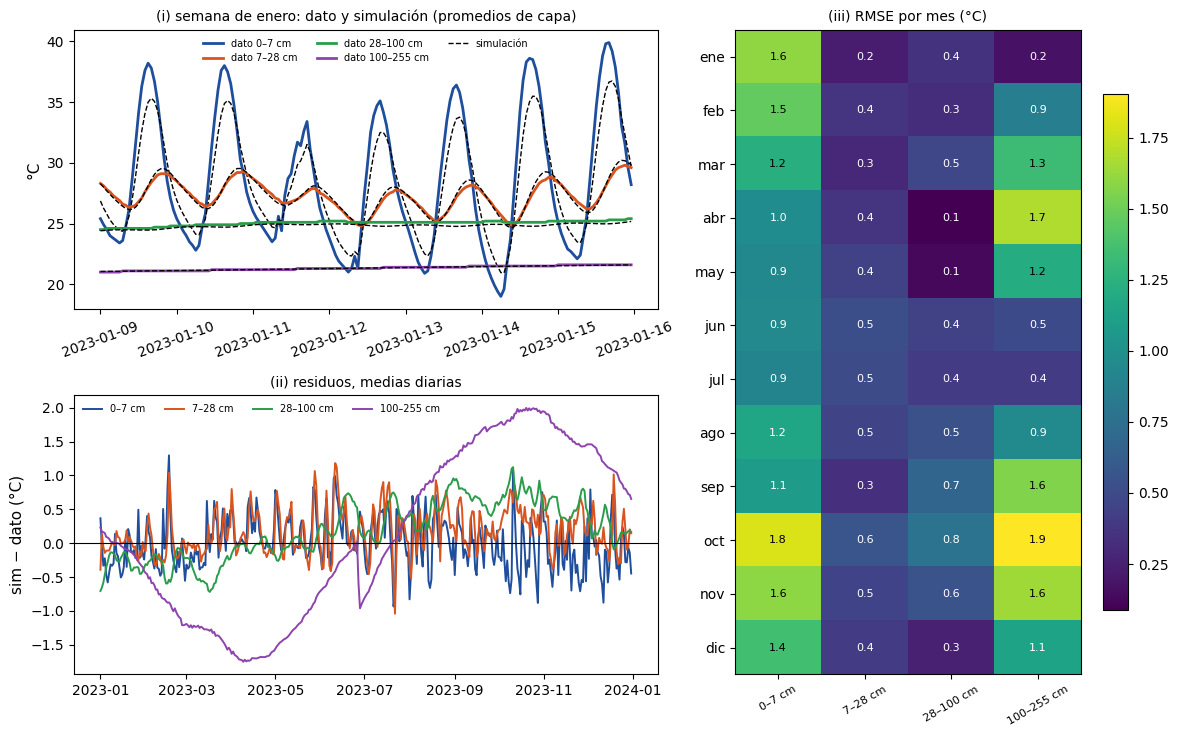

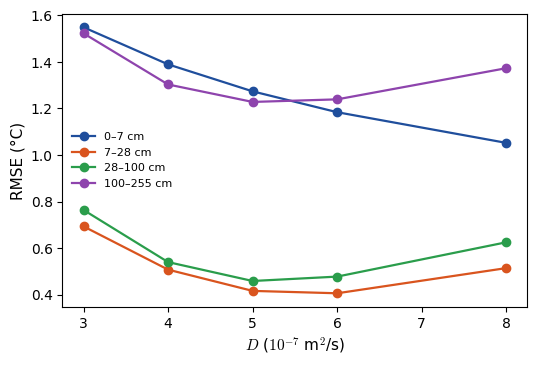

In [12]:
def promedios_capa(u, x):
    """Temperatura media de cada capa: regla del trapecio acumulada, interpolada en los bordes de las capas."""
    F = np.concatenate([[0.0], np.cumsum(0.5 * (u[1:] + u[:-1]) * np.diff(x))])
    return np.diff(np.interp(bordes, x, F)) / np.diff(bordes)

def simular_suelo(D, Ts, L=10.0, dx=0.01, spin=31, fondo="T", T_capas_ini=None, T_fondo=None, r_max=0.4):
    """Esquema explícito para u_t = D u_xx en (0, L) con u(0, t) = Ts(t) (dato horario, interpolado linealmente).
    Devuelve (capas, x, u_min): promedio por capa en cada hora, grilla y mínimo de u en cada nodo."""
    assert L > bordes[-1], "L debe ser mayor que el fondo de la última capa"
    N_ = len(Ts)
    F = Ts[np.arange(-spin * 24, N_) % N_]                    # forzado: spin-up (últimos días del registro) + registro
    x = np.arange(int(round(L / dx)) + 1) * dx
    T_capas_ini = Y.mean(axis=0) if T_capas_ini is None else np.asarray(T_capas_ini, float)
    T_fondo = T_capas_ini[-1] if T_fondo is None else T_fondo
    u = np.interp(x, x_m, T_capas_ini)                        # dato inicial: perfil medio
    m = int(np.ceil(3600 * D / (r_max * dx ** 2)))            # sub-pasos por hora
    r = D * (3600 / m) / dx ** 2
    assert r <= 0.5
    capas = np.empty((N_, 4)); u_min = np.full(len(x), np.inf)
    for i in range(len(F) - 1):
        if i >= spin * 24:
            capas[i - spin * 24] = promedios_capa(u, x)
            u_min = np.minimum(u_min, u)
        for j in range(1, m + 1):
            u[1:-1] += r * (u[2:] - 2 * u[1:-1] + u[:-2])
            u[0] = F[i] + (F[i + 1] - F[i]) * j / m
            u[-1] = T_fondo if fondo == "T" else u[-2]
    capas[-1] = promedios_capa(u, x)
    return capas, x, u_min

# (b) el año
D_sim = np.sqrt(D_capa_a * D_capa_d)
print(f"\nD_sim = {D_sim:.2e} m²/s (media geométrica de las dos estimaciones de la Tarea 4)")
sim, x_g, _ = simular_suelo(D_sim, Y[:, 0])
res_sim = sim - Y
sesgo, rmse = res_sim.mean(axis=0), np.sqrt((res_sim ** 2).mean(axis=0))
print(pd.DataFrame({"sesgo (°C)": sesgo, "RMSE (°C)": rmse, "desvío del dato (°C)": Y.std(axis=0)}, index=nombres).round(2).to_string())

mes = suelo.fecha_hora.dt.month.values
rmse_mes = np.array([np.sqrt((res_sim[mes == m_] ** 2).mean(axis=0)) for m_ in range(1, 13)])     # 12 x 4
sesgo_mes = np.array([res_sim[mes == m_].mean(axis=0) for m_ in range(1, 13)])
print("\nsesgo por mes (filas: ene-dic; columnas: capas):\n", np.round(sesgo_mes, 2))

fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 2, width_ratios=[1.35, 1])
ax1 = fig.add_subplot(gs[0, 0]); ax2 = fig.add_subplot(gs[1, 0]); ax3 = fig.add_subplot(gs[:, 1])
sem = (suelo.fecha_hora >= "2023-01-09") & (suelo.fecha_hora < "2023-01-16")
for i in range(4):
    ax1.plot(suelo.fecha_hora[sem], Y[sem, i], color=CICLO[i], lw=2, label=f"dato {nombres[i]}")
    ax1.plot(suelo.fecha_hora[sem], sim[sem, i], "--", color="black", lw=1)
ax1.plot([], [], "--", color="black", lw=1, label="simulación"); ax1.set_ylabel("°C"); ax1.set_title("(i) semana de enero: dato y simulación (promedios de capa)", fontsize=10)
ax1.legend(fontsize=7, ncol=3, loc="upper center"); ax1.tick_params(axis="x", labelrotation=20)
rd = pd.DataFrame(res_sim, index=suelo.fecha_hora).resample("D").mean()
for i in range(4):
    ax2.plot(rd.index, rd.iloc[:, i], color=CICLO[i], lw=1.4, label=nombres[i])
ax2.axhline(0, color="k", lw=0.8); ax2.set_ylabel("sim − dato (°C)"); ax2.set_title("(ii) residuos, medias diarias", fontsize=10); ax2.legend(fontsize=7, ncol=4, loc="upper left")
im = ax3.imshow(rmse_mes, aspect="auto", cmap="viridis")
ax3.set_xticks(range(4), nombres, rotation=30, fontsize=8); ax3.set_yticks(range(12), ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"])
for a_ in range(12):
    for b_ in range(4):
        ax3.text(b_, a_, f"{rmse_mes[a_, b_]:.1f}", ha="center", va="center", color="white" if rmse_mes[a_, b_] < 1.2 else "black", fontsize=8)
ax3.set_title("(iii) RMSE por mes (°C)", fontsize=10); fig.colorbar(im, ax=ax3, shrink=0.8)
fig.tight_layout()

# (c) sensibilidad numérica y de modelado: diferencia máxima con la corrida base, por capa
variantes = {"L = 5 m": dict(L=5.0), "flujo nulo (L = 10 m)": dict(fondo="F"), "spin-up de un año": dict(spin=365), "dx = 2 cm": dict(dx=0.02)}
filas_c = []
for nombre, kw in variantes.items():
    s_v, _, _ = simular_suelo(D_sim, Y[:, 0], **kw)
    filas_c.append(np.abs(s_v - sim).max(axis=0))
print("\n(c) diferencia máxima con la corrida base (°C):")
print(pd.DataFrame(filas_c, index=list(variantes), columns=nombres).round(3).to_string())

# (d) barrido de D
Ds = np.array([3, 4, 5, 6, 8]) * 1e-7
rm_D = np.array([np.sqrt(((simular_suelo(D_, Y[:, 0])[0] - Y) ** 2).mean(axis=0)) for D_ in Ds])
print("\n(d) RMSE (°C) por capa según D:")
print(pd.DataFrame(rm_D, index=[f"{D_:.0e}" for D_ in Ds], columns=nombres).round(2).to_string())
print("D que minimiza el RMSE en cada capa:", [f"{Ds[k]:.0e}" for k in rm_D.argmin(axis=0)])
fig_D, ax = plt.subplots(figsize=(6, 3.8))
for i in range(4):
    ax.plot(1e7 * Ds, rm_D[:, i], "o-", color=CICLO[i], label=nombres[i])
ax.set_xlabel(r"$D$ ($10^{-7}$ m$^2$/s)"); ax.set_ylabel("RMSE (°C)"); ax.legend(fontsize=8)

In [13]:
# Verificación: forzado exactamente periódico, 30 días; la solución tiene que ser el promedio de u_per sobre cada capa
t30 = np.arange(720) * 3600.0
Ts_test = 20 + 5 * np.cos(omega_d * t30)
sim_t = simular_suelo(D_tipico, Ts_test, spin=15, T_capas_ini=[20] * 4)[0]
exacta = np.array([20 + np.real(5 * ganancia(delta_de(D_tipico, omega_d), bordes[i], bordes[i + 1]) * np.exp(1j * omega_d * t30)) for i in range(4)]).T
err_a = np.abs(sim_t - exacta)[-240:].max(axis=0)
print("error máximo de la simulación contra u_per promediada, últimos 10 días, por capa (°C):", np.round(err_a, 3))
assert sim_t.shape == (720, 4) and err_a.max() < 0.1, "la simulación no reproduce la solución periódica"
try:
    simular_suelo(D_tipico, Ts_test[:48], L=2.0); raise RuntimeError("debería haber fallado con L = 2 m")
except AssertionError:
    pass
print("simulación: OK")

error máximo de la simulación contra u_per promediada, últimos 10 días, por capa (°C): [0.017 0.006 0.    0.   ]
simulación: OK


**Para el docente.** Con $D_{sim} = 4.85\times10^{-7}$ (media geométrica de $5.94\times10^{-7}$ y $3.96\times10^{-7}$): sesgo $(0.00,\ 0.17,\ 0.19,\ 0.13)$ °C y RMSE $(1.29,\ 0.42,\ 0.46,\ 1.23)$ °C, contra desvíos de los datos de $7.2$, $5.8$, $4.7$, $3.6$ °C. Capa $0$–$7$ cm: el error es de la comparación (el promedio de la solución sobre $7$ cm tiene el $\approx 75\,\%$ de la amplitud diaria del borde, que es el propio promedio del dato); la Tarea 8 lo corrige. Capa profunda: el residuo tiene estructura estacional muy clara, de $-1.7$ °C en abril a $+1.9$ °C en octubre (la simulación *adelanta* al dato: el dato llega más tarde, coherente con el $D$ de fase anual chico) y no viene de las decisiones numéricas: las variantes de (c) cambian la capa profunda hasta $0.32$ ($L = 5$ m) y $0.27$ °C (spin-up de un año), $0.016$ °C (flujo nulo), y las capas de $0$ a $100$ cm menos de $0.12$ °C ($\Delta x = 2$ cm: $0.05$ °C). RMSE mensual: las capas intermedias van de $0.1$ a $0.8$ °C, peores en octubre–noviembre (primavera), mejores en abril–mayo; la capa superficial es peor en octubre ($1.8$ °C) y en enero–febrero ($1.5$ a $1.6$ °C). Barrido de $D$ ($3,4,5,6,8\times10^{-7}$): mínimos en $8, 6, 5, 5\times10^{-7}$ para las cuatro capas (RMSE de la capa $7$–$28$: $0.69, 0.51, 0.42, 0.41, 0.51$); el valle es plano entre $5$ y $6\times10^{-7}$. Errores típicos: no hacer los sub-pasos (con $\Delta t = 3600$ s el esquema explota: $r = 18$ con $D = 5\times10^{-7}$); comparar la simulación en $x_m$ con el dato (en lugar de promediar); interpolar mal el borde (usar el dato horario constante en cada hora: se nota en la capa superficial); olvidar que $m$ depende de $D$. Tiempo: 60 minutos (la simulación tarda unos $2$ s; el barrido y las variantes unos $20$ s).

## 6. Con un mes de datos: ¿cuánta precisión es razonable?

En la práctica no siempre hay un año de registros: una campaña de medición puede durar semanas. ¿Cuánto cambia $D$ si solo se usa un mes? Con un mes **no se puede estimar el ciclo anual** (el registro es más corto que el período: el ciclo anual se ve como una tendencia), pero sí el diario: en 31 días hay 31 ciclos completos.

**Cómo estimar.** Para cada mes se ajusta a cada capa, por mínimos cuadrados con frecuencia fija (Sección 2), una **tendencia cúbica** más los armónicos $\omega_d$ y $2\omega_d$ (la tendencia absorbe la parte lenta: el ciclo anual y los cambios de tiempo; el armónico de 12 h, que en la capa superficial tiene una amplitud de más de $1$ °C, evita que la forma no sinusoidal del ciclo diario lo contamine). Con la amplitud y la fase de las tres capas superficiales se calculan tres estimaciones de $D$ del ciclo diario: por amplitud y por fase con las dos primeras capas (como en la Tarea 3), y con el ajuste con promedio de capa de las tres (como en la Tarea 4).

**Qué se espera.** Las estimaciones mensuales varían entre meses en un $\pm 10$–$20\,\%$ alrededor de su media ($\approx 4\times10^{-7}$), con una estructura estacional (las tres son mayores de abril a septiembre, otoño e invierno, y menores de octubre a marzo), y el orden entre los métodos casi siempre se mantiene ($D$ por fase mayor que por amplitud). Esa estructura es información, no ruido: sugiere que $D$ **no es constante** (la conductividad térmica del suelo mojado es mucho mayor que la del seco, y depende de la temperatura; es una hipótesis que este laboratorio no prueba). Una campaña de un mes da entonces un $D$ *de ese mes*, con una variación de decenas de por ciento respecto de otro mes y del $D$ "de todo el año". Comparar, para enero y julio, con las estimaciones del año completo.

### Tarea 6: Un mes de verano y uno de invierno (y los demás)

Escribí `D_del_mes(m)`: con las filas del mes `m` (`mes = suelo.fecha_hora.dt.month.values`), ajusta con `ls_ciclos(..., [omega_d, 2*omega_d], grado=3)` las tres capas superficiales, y devuelve las tres estimaciones de $D$: por amplitud (dos capas), por fase (dos capas) y con promedio de capa (tres capas, `ajustar_capas`).

Calculalo para los 12 meses; hacé una tabla y graficá las tres estimaciones contra el mes, marcando enero (verano) y julio (invierno), junto con las líneas horizontales de las estimaciones del año completo de la Tarea 3 (diario) y de $D_{capa}$ de la Tarea 4. Resumí, para cada método, la media y el desvío entre meses.

**Qué se espera.** Valores entre $2\times10^{-7}$ y $6\times10^{-7}$ m$^2$/s: dentro de un factor 2 del valor típico, con dispersión entre meses de $10$–$20\,\%$. El $D$ por fase es mayor que el $D$ por amplitud en casi todos los meses, y el de capa (tres capas) es del mismo orden. Anotá qué mes da el $D$ más bajo y cuál el más alto, y si enero y julio difieren entre sí más que lo que difieren los métodos.

     D amplitud   D fase  D capa (3 capas)
ene    2.87e-07 4.14e-07          3.79e-07
feb    3.23e-07 4.02e-07          4.09e-07
mar    3.14e-07 4.23e-07          3.93e-07
abr    4.31e-07 4.12e-07          5.29e-07
may    4.40e-07 4.80e-07          4.06e-07
jun    4.24e-07 5.16e-07          4.44e-07
jul    4.20e-07 5.11e-07          4.78e-07
ago    3.61e-07 5.01e-07          4.43e-07
sep    3.86e-07 4.98e-07          4.17e-07
oct    2.36e-07 3.90e-07          3.47e-07
nov    3.01e-07 4.40e-07          3.84e-07
dic    3.30e-07 4.19e-07          3.79e-07

media ± desvío entre meses:
  D amplitud        : 3.54e-07 ± 6.6e-08  (cociente máx/mín = 1.86)
  D fase            : 4.51e-07 ± 4.7e-08  (cociente máx/mín = 1.32)
  D capa (3 capas)  : 4.17e-07 ± 5.0e-08  (cociente máx/mín = 1.53)

enero: [2.867e-07 4.141e-07 3.791e-07]; julio: [4.201e-07 5.106e-07 4.782e-07]
año completo (Tareas 3 y 4): amplitud 3.33e-07, fase 4.45e-07, capa (3 capas) 3.96e-07


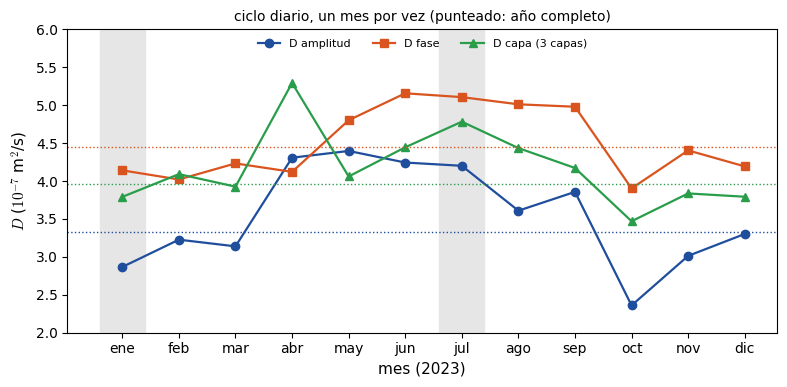

In [14]:
mes = suelo.fecha_hora.dt.month.values

def D_del_mes(m):
    """Devuelve (D por amplitud, D por fase, D con promedio de capa) del ciclo diario del mes m."""
    sel = mes == m
    ap = np.array([ls_ciclos(Y[sel, i], t[sel], [omega_d, 2 * omega_d], grado=3)[0] for i in range(3)])     # (A, phi) de omega_d
    A, P = ap[:, 0], ap[:, 1]
    D_amp = estimar(x_m[:2], np.log(A[:2]), omega_d, "amp")[2]
    D_fase = estimar(x_m[:2], retraso_de_fase(P[:2]), omega_d, "fase")[2]
    D_cap = ajustar_capas(A * np.exp(1j * P), range(3), omega_d)["D"]
    return D_amp, D_fase, D_cap

meses = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
D_meses = np.array([D_del_mes(m_) for m_ in range(1, 13)])
tabla6 = pd.DataFrame(D_meses, index=meses, columns=["D amplitud", "D fase", "D capa (3 capas)"])
print(tabla6.to_string(float_format=lambda v: f"{v:.2e}"))
print("\nmedia ± desvío entre meses:")
for c in tabla6:
    print(f"  {c:18s}: {tabla6[c].mean():.2e} ± {tabla6[c].std():.1e}  (cociente máx/mín = {tabla6[c].max() / tabla6[c].min():.2f})")
print(f"\nenero: {D_meses[0].round(10)}; julio: {D_meses[6].round(10)}")
print(f"año completo (Tareas 3 y 4): amplitud {est[('diario', 'amp')][2]:.2e}, fase {est[('diario', 'fase')][2]:.2e}, capa (3 capas) {D_capa_d:.2e}")

fig, ax = plt.subplots(figsize=(8, 4))
for j, (c, k, mk) in enumerate(zip(tabla6, [COLORES["dato"], COLORES["modelo"], COLORES["nul_p"]], ["o", "s", "^"])):
    ax.plot(range(1, 13), 1e7 * tabla6[c], mk + "-", color=k, label=c)
for val, k, ls in [(est[("diario", "amp")][2], COLORES["dato"], ":"), (est[("diario", "fase")][2], COLORES["modelo"], ":"), (D_capa_d, COLORES["nul_p"], ":")]:
    ax.axhline(1e7 * val, color=k, ls=ls, lw=1)
for m_ in (1, 7):
    ax.axvspan(m_ - 0.4, m_ + 0.4, color="0.9", zorder=0)
ax.set_xticks(range(1, 13), meses); ax.set_ylabel(r"$D$ ($10^{-7}$ m$^2$/s)"); ax.set_xlabel("mes (2023)")
ax.set_ylim(2.0, 6.0); ax.legend(fontsize=8, ncol=3, loc="upper center"); ax.set_title("ciclo diario, un mes por vez (punteado: año completo)", fontsize=10)
fig.tight_layout()

In [15]:
# Verificación
_ene, _jul = D_del_mes(1), D_del_mes(7)
assert all(1e-7 < v < 1e-6 for v in (*_ene, *_jul)), "cada estimación mensual debería estar entre 1e-7 y 1e-6"
assert _ene[1] > _ene[0] and _jul[1] > _jul[0], "por fase debería dar más que por amplitud"
print("un mes de datos: OK")

un mes de datos: OK


**Para el docente.** $D$ por mes ($10^{-7}$ m$^2$/s; amplitud / fase / capa): ene $2.9/4.1/3.8$, abr $4.3/4.1/5.3$, jul $4.2/5.1/4.8$, oct $2.4/3.9/3.5$. Media $\pm$ desvío entre meses: amplitud $3.5 \pm 0.7$ (máx/mín $1.9$), fase $4.5 \pm 0.5$ ($1.3$), capa $4.2 \pm 0.5$ ($1.5$); año completo: $3.3$, $4.5$, $4.0$. Las tres series suben de abril a septiembre y bajan en octubre. Enero (verano) y julio (invierno) difieren en $\approx 45\,\%$ por amplitud, $\approx 25\,\%$ por fase y $\approx 25\,\%$ por capa: menos que la diferencia entre métodos para el anual, pero más que las incertidumbres de la Tarea 3. Conclusión a exigir: con un mes, $D$ con $\pm 20$–$30\,\%$ (sistemático, no de ruido) y solo del ciclo diario; el anual no se puede. Errores típicos: no incluir la tendencia (un mes de otoño con enfriamiento sesga la amplitud diaria); no incluir el armónico $2\omega_d$; estimar el anual con un mes. Tiempo: 25 minutos.

## 7. ¿A qué profundidad enterrar una cañería? (pregunta 5)

**Con la solución periódica.** Para el ciclo anual, $u_{per} = \bar T + A e^{-x/\delta_a}\cos(\omega_a t - x/\delta_a + \varphi_s)$ y la temperatura **mínima del año** a profundidad $x$ es $\bar T - A e^{-x/\delta_a}$ (el mínimo del coseno). La cañería no se congela si esa mínima es positiva:

$$\bar T - A e^{-x/\delta_a} > 0 \iff x > x^* = \delta_a\ln\frac{A}{\bar T}\qquad(\text{si } A > \bar T;\ \text{si no, no se congela ni en la superficie}).$$

Como $\delta_a = \sqrt{2D/\omega_a}$, **$x^*$ es proporcional a $\sqrt D$**: un error del $50\,\%$ en $D$ es un error del $22\,\%$ en la profundidad. Es la razón por la que la respuesta útil no es "$x^* = 2.4$ m" sino un *rango*, que sale de la incertidumbre de $D$ (Tareas 3, 4 y 6): con las cuatro estimaciones de la Tarea 3, $x^*$ va de unos $2$ m a más de $4$ m para el mismo clima. Los parámetros que entran son la temperatura media $\bar T$ y la amplitud anual $A$ **de la superficie**: usamos $\bar T$ de la capa superficial y $A = A_0$ del ajuste con promedio de capa (Tarea 4).

**Lo que la fórmula no tiene.** (i) El ciclo anual real no es un coseno perfecto: hay olas de frío de días o semanas que bajan la temperatura de la superficie por debajo de $\bar T - A$, y penetran menos (una perturbación de período $\tau$ penetra $\delta = \sqrt{D\tau/\pi}$: unos $0.4$ m para dos semanas). (ii) Los extremos diarios se apagan en los primeros $30$ cm. (iii) El congelamiento libera calor latente y cambia $D$. Por eso conviene *verificar* la fórmula con una simulación (la Tarea 5 con otro forzado) y agregar **un margen**.

**La simulación como verificación.** Para el clima frío hipotético ($\bar T = 5$ °C, $A = 15$ °C) construimos un forzado con el mismo *tiempo* meteorológico del dato, reescalado: $T_s^{frío}(t) = 5 + \frac{15}{A_s}\bigl(T_s(t) - \overline{T_s}\bigr)$ con $A_s$ la amplitud anual de la capa superficial (así conserva los ciclos diarios y las olas de frío, ahora amplificados). Se simula con un *spin-up* de **dos años** (repitiendo el forzado cíclicamente: la solución converge al atractor periódico, que es el estado que describe la solución periódica; el dato inicial se olvida), dato inicial $5$ °C, y se lee el mínimo de $u$ en cada profundidad a lo largo del año, `u_min` (ya lo devuelve `simular_suelo`).

**Qué se espera.** Para Buenos Aires ($\bar T \approx 19$ °C, $A \approx 8.7$ °C): $A < \bar T$, no hay congelamiento, y la mínima anual del modelo periódico es de unos $10$ °C en la superficie (la mínima horaria real de la capa superficial es de $1$ °C: la fórmula no ve los extremos diarios ni las olas de frío; de $64$ cm hacia abajo el mínimo del dato ya está a $1$ °C de la curva). Para el clima frío: $x^* = \delta_a\ln 3 \approx 1.1\,\delta_a$, es decir entre $2$ y $4.4$ m según el $D$ (con el ajuste de la Tarea 4, unos $2.7$ m); la simulación, que tiene los extremos y las olas de frío, da **prácticamente lo mismo que la fórmula con el mismo $D$** (un desvío de centímetros) aunque la mínima en la superficie es mucho más baja: los extremos rápidos se apagan antes de los $50$ cm. Conclusión: la incertidumbre que domina es la de $D$, no la del clima.

### Tarea 7: La cañería, con los valores ajustados y con un clima frío

Escribí `x_libre(T_media, A, delta)`, la profundidad mínima $x^*$ (0 si no hay congelamiento en la superficie).

**(a) Buenos Aires.** Con $\bar T$ = media de la capa superficial, $A = A_0$ (amplitud anual en $x=0$ del ajuste con promedio de capa de la Tarea 4: `fit4[("anual", 4, "capa")]["A0"]`) y $D = D_{capa,a}$, ¿se congela? Calculá la mínima anual del modelo periódico a cada profundidad y compará con el mínimo del dato de cada capa (`Y.min(axis=0)`).

**(b) Clima frío hipotético.** Con $\bar T = 5$ °C y $A = 15$ °C, calculá $x^*$ para cada uno de los $D$ estimados (las cuatro estimaciones de la Tarea 3, `D_capa_a`, `D_capa_d` y `D_tipico`) y armá una tabla con $\delta_a$ y $x^*$.

**(c) Verificación con la simulación.** Con el forzado reescalado `Ts_frio` de arriba y `D = D_sim`, corré `simular_suelo(..., spin=730, T_capas_ini=[5]*4, T_fondo=5)` y sacá de `u_min` la profundidad a la que la mínima del año cruza $0$ °C. Compará con la fórmula (con el mismo $D$) y con el rango de (b). Graficá en dos paneles: (a) Buenos Aires: mínima anual del modelo periódico contra $x$ y los mínimos del dato (marcados en $x_m$); (b) clima frío: $\bar T - A e^{-x/\delta_a}$ para tres valores de $D$ y el `u_min` de la simulación.

**Qué se espera.** Buenos Aires: no se congela (mínima del modelo $\approx 10.6$ °C en la superficie; el mínimo horario real de la capa superficial es mucho menor, de una noche de invierno, y de $64$ cm hacia abajo el mínimo del dato está cerca de la curva). Clima frío: $x^*$ entre $2$ y $4.4$ m según el $D$; la simulación, muy cerca de la fórmula con el mismo $D$.

(a) Buenos Aires: T_media = 19.3 °C, A0 = 8.7 °C, delta_a = 2.44 m, x* = 0.00 m; mínima anual en la superficie: 10.6 °C
    mínima anual del modelo periódico en x_m (°C): [10.7 11.2 12.6 15.1]
    mínimo horario del dato en cada capa (°C):     [ 1.2  5.7 11.4 14.3]

(b) clima frío (T_media = 5, A = 15):
 estimación de D  D (m²/s)  delta_a (m)  x* (m)
 anual fase (T3)  3.12e-07         1.77    1.95
 diario amp (T3)  3.33e-07         1.83    2.01
diario capa (T4)  3.96e-07         1.99    2.19
diario fase (T3)  4.45e-07         2.11    2.32
          típico     5e-07         2.24    2.46
 anual capa (T4)  5.94e-07         2.44    2.68
  anual amp (T3)  1.58e-06         3.99    4.38



(c) D_sim = 4.85e-07: fórmula x* = 2.42 m; simulación: la mínima del año cruza 0 °C en x = 2.39 m
    mínima de la simulación en la superficie: -29.0 °C (el modelo periódico: -10.0 °C)


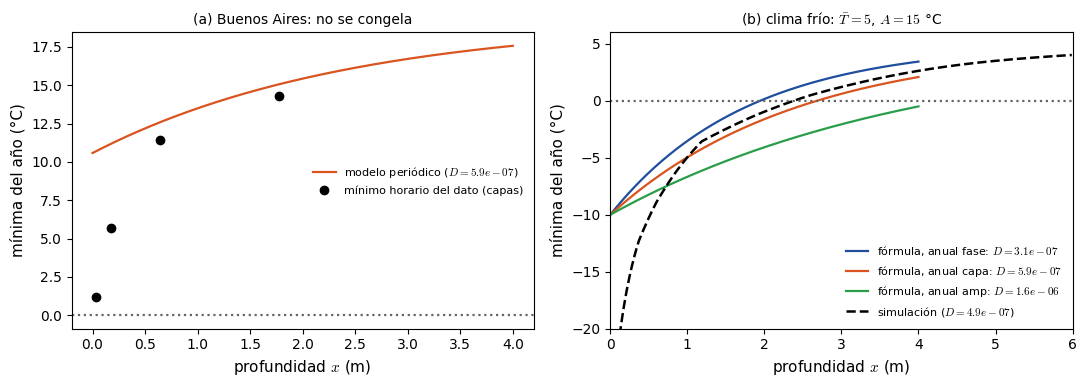

In [16]:
def x_libre(T_media, A, delta):
    """Profundidad mínima para que la mínima anual T_media - A exp(-x/delta) sea positiva (0 si no hay congelamiento)."""
    return delta * np.log(A / T_media) if A > T_media else 0.0

# (a) Buenos Aires
T_BA, A_BA = Y[:, 0].mean(), fit4[("anual", 4, "capa")]["A0"]
d_a = delta_de(D_capa_a, omega_a)
print(f"(a) Buenos Aires: T_media = {T_BA:.1f} °C, A0 = {A_BA:.1f} °C, delta_a = {d_a:.2f} m, x* = {x_libre(T_BA, A_BA, d_a):.2f} m; mínima anual en la superficie: {T_BA - A_BA:.1f} °C")
print("    mínima anual del modelo periódico en x_m (°C):", np.round(T_BA - A_BA * np.exp(-x_m / d_a), 1))
print("    mínimo horario del dato en cada capa (°C):    ", np.round(Y.min(axis=0), 1))

# (b) clima frío, para cada D
D_lista = {"típico": D_tipico, "anual fase (T3)": est[("anual", "fase")][2], "diario amp (T3)": est[("diario", "amp")][2], "diario fase (T3)": est[("diario", "fase")][2],
           "diario capa (T4)": D_capa_d, "anual capa (T4)": D_capa_a, "anual amp (T3)": est[("anual", "amp")][2]}
filas7 = [[nombre, D_, delta_de(D_, omega_a), x_libre(5.0, 15.0, delta_de(D_, omega_a))] for nombre, D_ in sorted(D_lista.items(), key=lambda kv: kv[1])]
print("\n(b) clima frío (T_media = 5, A = 15):")
print(pd.DataFrame(filas7, columns=["estimación de D", "D (m²/s)", "delta_a (m)", "x* (m)"]).to_string(index=False, float_format=lambda v: f"{v:.3g}"))

# (c) simulación con el forzado reescalado
A_s = tab_dft.loc["0–7 cm", "A_anual"]
Ts_frio = 5 + 15 / A_s * (Y[:, 0] - Y[:, 0].mean())
_, x_g, u_min = simular_suelo(D_sim, Ts_frio, spin=730, T_capas_ini=[5] * 4, T_fondo=5.0)
x_sim = x_g[np.argmax(u_min > 0)]
d_sim = delta_de(D_sim, omega_a)
print(f"\n(c) D_sim = {D_sim:.2e}: fórmula x* = {x_libre(5.0, 15.0, d_sim):.2f} m; simulación: la mínima del año cruza 0 °C en x = {x_sim:.2f} m")
print(f"    mínima de la simulación en la superficie: {u_min[0]:.1f} °C (el modelo periódico: {5 - 15:.1f} °C)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
xg = np.linspace(0, 4, 300)
ax1.plot(xg, T_BA - A_BA * np.exp(-xg / d_a), color=COLORES["modelo"], label=rf"modelo periódico ($D={D_capa_a:.1e}$)")
ax1.plot(x_m, Y.min(axis=0), "ko", label="mínimo horario del dato (capas)")
ax1.axhline(0, color="0.4", ls=":"); ax1.set_xlabel("profundidad $x$ (m)"); ax1.set_ylabel("mínima del año (°C)"); ax1.set_title("(a) Buenos Aires: no se congela", fontsize=10); ax1.legend(fontsize=8, loc="center right")
for (nombre, D_), c in zip([("anual fase", est[("anual", "fase")][2]), ("anual capa", D_capa_a), ("anual amp", est[("anual", "amp")][2])], CICLO):
    ax2.plot(xg, 5 - 15 * np.exp(-xg / delta_de(D_, omega_a)), color=c, label=rf"fórmula, {nombre}: $D={D_:.1e}$")
ax2.plot(x_g[x_g < 6], u_min[x_g < 6], "k--", lw=1.8, label=rf"simulación ($D={D_sim:.1e}$)")
ax2.axhline(0, color="0.4", ls=":"); ax2.set_xlim(0, 6); ax2.set_ylim(-20, 6); ax2.set_xlabel("profundidad $x$ (m)"); ax2.set_ylabel("mínima del año (°C)")
ax2.set_title(r"(b) clima frío: $\bar T = 5$, $A = 15$ °C", fontsize=10); ax2.legend(fontsize=8, loc="lower right")
fig.tight_layout()

In [17]:
# Verificación
assert x_libre(19.0, 8.0, 2.2) == 0.0 and abs(x_libre(5.0, 15.0, 2.24) - 2.24 * np.log(3)) < 1e-12
print("cañería: OK")

cañería: OK


**Para el docente.** Buenos Aires: $\bar T = 19.3$ °C, $A_0 = 8.7$ °C, $\delta_a = 2.44$ m: $A < \bar T$, no se congela (mínima del modelo $10.6$ °C en la superficie, $10.7$, $11.2$, $12.6$, $15.1$ °C en $x_m$); mínimos horarios del dato: $1.2$, $5.7$, $11.4$, $14.3$ °C (las dos capas profundas quedan a $1$ °C de la curva; las superficiales, muy por debajo: extremos y olas de frío). Clima frío ($\bar T = 5$, $A = 15$): $x^*$ = $1.95$ m ($D = 3.1\times10^{-7}$, anual por fase), $2.01$ ($3.3\times10^{-7}$), $2.19$ ($4.0\times10^{-7}$), $2.32$ ($4.45\times10^{-7}$), $2.46$ (típico), $2.68$ ($5.9\times10^{-7}$) y $4.38$ m ($1.6\times10^{-6}$, anual por amplitud sin corregir: descartable, ver Tarea 4). Simulación con $D_{sim} = 4.85\times10^{-7}$: cruza $0$ °C en $x = 2.39$ m; la fórmula da $2.42$ m; la mínima simulada en la superficie es $-29$ °C, contra $-10$ °C del modelo periódico (el forzado reescalado incluye los extremos), pero el efecto se apaga antes de los $50$ cm. Discusión: la fórmula es buena y el error dominante es el de $D$ ($x^* \propto \sqrt{D}$: un $\pm 30\,\%$ en $D$ es un $\pm 15\,\%$ en $x^*$, unos $\pm 0.35$ m); un margen de $0.3$ a $0.5$ m cubre eso, y las olas de frío de $1$ a $2$ semanas ($\delta \approx 0.3$ a $0.4$ m) están dentro de ese margen. Errores típicos: olvidar que la fórmula solo vale si $A > \bar T$; usar $A$ de la capa superficial en lugar de $A_0$ (diferencia de un $9\,\%$ en $A$: $0.2$ m); leer $\bar T$ del aire. Tiempo: 30 minutos.

## 8. (Opcional) El aire como borde, y un borde corregido

La Sección 5 argumentó que la capa superficial es mejor forzado que el aire. Acá se mide. Se comparan tres bordes con el mismo $D$ y la misma simulación:

1. **el aire** (`t_aire`), la primera aproximación que sugiere el enunciado;
2. **la capa $0$–$7$ cm** (la Tarea 5);
3. **la capa $0$–$7$ cm *corregida* por su promedio**: el dato es $\bar u_{[0,b]}$ ($b = 7$ cm), y lo que necesita el modelo es $u(0,t)$. Por la Tarea 4, cada componente de frecuencia $\omega$ de $u(0,t)$ aparece en el promedio multiplicada por $g(\delta(\omega); 0, b)$ (con $\delta(\omega) = \sqrt{2D/\omega}$); entonces se recupera $u(0,t)$ **dividiendo el espectro de la capa por $g(\delta(\omega);0,b)$** en cada frecuencia (una *deconvolución*, que amplifica las frecuencias altas: a $\omega$ horaria, $|g|\approx 0.4$: es una amplificación moderada y no hay problema de ruido) y antitransformando. Con `imc.espectro.filtrar(x, dt, mascara)` es una línea: `mascara(xi)` devuelve los factores complejos $1/g$, con $\omega = 2\pi\xi$ y el factor $1$ en $\xi = 0$.

**Qué se espera.** El RMSE con el aire como borde es $2$–$3$ veces mayor que con la capa superficial en las capas intermedias (y casi igual en la profunda, donde domina otra falla del modelo); parte del error es un sesgo de $-1$ °C (el suelo es en promedio más caliente que el aire, por la radiación) y el resto es la amplitud diaria y la fase, y ningún $D$ lo compensa. La corrección deja el error de la capa $0$–$7$ cm en unas centésimas de grado (ojo: es casi automático, es la capa con la que se construyó el borde), no cambia las profundas, y **empeora un poco la capa $7$–$28$ cm**: con el borde corregido el modelo homogéneo ya no puede acomodar a la vez a las dos capas superficiales, y el error se traslada. Es una señal más de que el modelo de una sola $D$ no es del todo correcto para este dato.

### Tarea 8: (Opcional) El aire como borde y el borde corregido

Escribí `borde_corregido(y, D, b=0.07)`: aplica `espectro.filtrar` con la máscara $1/g(\delta(\omega); 0, b)$ (con $g$ de la Tarea 4; `mascara` recibe `xi` en Hz y tiene que devolver un array complejo del mismo largo, valiendo 1 en `xi = 0`) y devuelve la serie corregida. Verificá que la media no cambia y que el desvío aumenta entre un $5$ y un $20\,\%$.

Simulá con los tres bordes (aire, capa $0$–$7$, capa corregida) con `D_sim` y calculá el RMSE y el sesgo de cada capa. Graficá el RMSE por capa como barras agrupadas.

**Qué se espera.** Ver arriba. Anotá para cada capa cuál de los tres bordes gana y qué parte del error del aire es sesgo (usá $\text{RMSE}^2 = \text{sesgo}^2 + \text{varianza}$).

media: 19.261 -> 19.261;  desvío: 7.24 -> 8.08 (+12 %)


RMSE (°C):
            aire  capa 0–7 cm  capa 0–7 cm corregida
0–7 cm      2.56         1.29                   0.06
7–28 cm     1.33         0.42                   0.52
28–100 cm   1.13         0.46                   0.47
100–255 cm  1.44         1.23                   1.23
sesgo (°C):
            aire  capa 0–7 cm  capa 0–7 cm corregida
0–7 cm     -1.01         0.00                   0.00
7–28 cm    -0.81         0.17                   0.17
28–100 cm  -0.69         0.19                   0.18
100–255 cm -0.52         0.13                   0.12


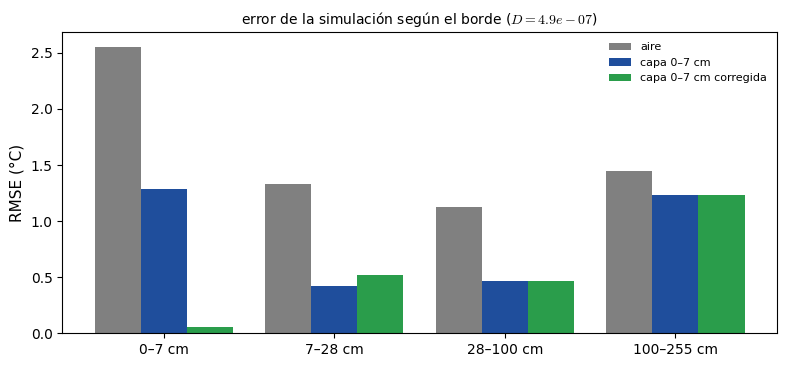

In [18]:
def borde_corregido(y, D, b=0.07):
    """Serie y (promedio de [0, b]) deconvolucionada para recuperar u(0, t): espectro / g(delta(omega); 0, b)."""
    def mascara(xi):
        om = 2 * np.pi * xi
        H = np.ones(len(xi), dtype=complex)
        H[1:] = 1 / ganancia(delta_de(D, om[1:]), 0.0, b)
        return H
    return espectro.filtrar(y, 3600.0, mascara)

Ts_corr = borde_corregido(Y[:, 0], D_sim)
print(f"media: {Y[:, 0].mean():.3f} -> {Ts_corr.mean():.3f};  desvío: {Y[:, 0].std():.2f} -> {Ts_corr.std():.2f} (+{100 * (Ts_corr.std() / Y[:, 0].std() - 1):.0f} %)")
bordes_sim = {"aire": aire, "capa 0–7 cm": Y[:, 0], "capa 0–7 cm corregida": Ts_corr}
rm8, sg8 = {}, {}
for nombre, T_b in bordes_sim.items():
    e = simular_suelo(D_sim, T_b)[0] - Y
    rm8[nombre], sg8[nombre] = np.sqrt((e ** 2).mean(axis=0)), e.mean(axis=0)
print("RMSE (°C):"); print(pd.DataFrame(rm8, index=nombres).round(2).to_string())
print("sesgo (°C):"); print(pd.DataFrame(sg8, index=nombres).round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 3.8))
ancho = 0.27
for k, (nombre, c) in enumerate(zip(rm8, [COLORES["gris"], COLORES["dato"], COLORES["nul_p"]])):
    ax.bar(np.arange(4) + (k - 1) * ancho, rm8[nombre], ancho, color=c, label=nombre)
ax.set_xticks(range(4), nombres); ax.set_ylabel("RMSE (°C)"); ax.set_title(f"error de la simulación según el borde ($D = {D_sim:.1e}$)", fontsize=10); ax.legend(fontsize=8)
fig.tight_layout()

In [19]:
# Verificación
_c = borde_corregido(Y[:, 0], 5e-7)
assert abs(_c.mean() - Y[:, 0].mean()) < 1e-6 and 1.05 < _c.std() / Y[:, 0].std() < 1.25, "la corrección debe conservar la media y aumentar el desvío entre 5 y 25 %"
print("borde corregido: OK")

borde corregido: OK


**Para el docente.** Desvío de la capa superficial $7.24 \to 8.08$ °C ($+12\,\%$); RMSE con $D_{sim}$: aire $(2.56,\ 1.33,\ 1.13,\ 1.44)$, capa $(1.29,\ 0.42,\ 0.46,\ 1.23)$, capa corregida $(0.06,\ 0.52,\ 0.47,\ 1.23)$ °C; sesgo con el aire $(-1.01,\ -0.81,\ -0.69,\ -0.52)$ °C (con $\text{RMSE}^2 = \text{sesgo}^2 + \text{var}$, en $7$–$28$ cm el sesgo explica $0.66$ de los $1.77$ de MSE: el resto es amplitud y fase). La corrección arregla la capa $0$–$7$ (que era el defecto de la Tarea 5) pero empeora $7$–$28$ de $0.42$ a $0.52$: buena pregunta de discusión (el modelo homogéneo no puede con las dos capas a la vez). Tiempo: 30 a 40 minutos; es opcional. Si no hay tiempo, la Tarea 8 se puede hacer con solo el aire, calculando el RMSE con la función de la Tarea 5.

## Interpretación

Esta es la parte que se evalúa. Respondé en las celdas de texto que siguen, con oraciones completas y citando los números o gráficos que obtuviste.

**1.** **El modelo y el borde (pregunta 1 del problema).** Escribí el problema que simulaste: la ecuación, el dominio, las condiciones de borde y el dato inicial, y justificá cada elección (por qué $L = 10$ m y esa condición inferior; por qué la capa superficial y no el aire, con los errores de las Tareas 5 y 8). Enumerá al menos tres hipótesis del modelo que el suelo real (o el reanálisis) no cumple.

**2.** **Penetración (pregunta 2).** ¿Por qué el ciclo diario penetra menos que el anual? ¿Cuánto menos, y de qué depende la profundidad de penetración? Con tus $\delta$ de las Tareas 3 y 4 y las amplitudes de la Tarea 2, calculá qué fracción de la amplitud de la superficie llega a $17.5$ cm y a $64$ cm en cada ciclo, y compará con lo que dice la teoría ($e^{-x/\delta}$, cociente $\sqrt{365}$ entre los $\delta$).

**3.** **Retraso (pregunta 3).** ¿Cuánto vale el retraso a cada profundidad? Con tus estimaciones, dá el retraso del ciclo diario entre las capas $0$–$7$ y $7$–$28$ cm (en horas) y el del anual entre la capa $0$–$7$ y la $100$–$255$ cm (en días), y compará con $x/(\delta\omega)$. ¿Por qué el retraso *de una capa* no es el del punto medio, y cuándo importa (Tarea 4)?

**4.** **Estimar $D$ y comprobar el modelo (pregunta 4).** Resumí en una tabla tus estimaciones de $D$ (Tareas 3, 4, 5 y 6) con su incertidumbre. ¿Coinciden las cuatro estimaciones de la Tarea 3? ¿Deberían? Explicá por qué no, separando lo que *explica* el promedio de capa (con los números de la Tarea 4) de lo que *no* explica (¿qué queda entonces?), y qué te dicen sobre el modelo los residuos de la simulación (dónde y cuándo falla; humedad, lluvia, estratificación del suelo del reanálisis). Con la variación mes a mes de la Tarea 6, ¿qué precisión es razonable esperar de $D$, y qué valor y qué error informarías?

**5.** **La cañería (pregunta 5).** ¿A qué profundidad enterrarías la cañería en Buenos Aires y en el clima frío hipotético? Dá un *rango* (no un número) que refleje la incertidumbre de $D$, explicá por qué es proporcional a $\sqrt D$, y decidí qué margen agregarías, argumentando con lo que la simulación de la Tarea 7 tiene y la fórmula no.

### Respuestas modelo (para el docente)

**1.** El problema: $u_t = D u_{xx}$ en $0<x<L = 10$ m, $u(0,t) = T_s(t)$ con $T_s$ la temperatura horaria de la capa $0$–$7$ cm (interpolada linealmente entre horas), $u(L,t) = \bar T = 19.3$ °C (o flujo nulo: diferencia menor que $0.02$ °C), $u(x,0)$ = perfil medio ($\approx 19.2$ °C), con un mes de spin-up. $L = 10$ m porque la solución anual decae como $e^{-x/\delta_a}$ ($\delta_a \approx 2.4$ m): en $L$ queda un $1.7\,\%$; con $L = 5$ m la capa profunda cambia hasta $0.3$ °C. La capa superficial y no el aire: el aire tiene $2.76$ °C de amplitud diaria contra $4.03$ °C de la capa superficial y es $1$ °C más frío en promedio; con el aire de borde el RMSE es $1.33$ y $1.13$ °C en las capas intermedias, contra $0.42$ y $0.46$ °C con la capa superficial. Hipótesis que el dato no cumple (tres alcanzan, y la primera es la que más importa): suelo homogéneo (el reanálisis tiene capas de propiedades distintas y las amplitudes y las fases anuales lo delatan); solo conducción, sin agua (lluvia, evaporación, calor latente); $D$ constante (varía $\pm 15$–$20\,\%$ con el mes); forzado de Dirichlet en $x=0$ conocido (solo tenemos un promedio de $7$ cm); semiespacio sin fondo; el dato mismo es la salida de un modelo.

**2.** Porque $\delta = \sqrt{2D/\omega}$ y $\omega_d = 365\,\omega_a$: $\delta_d/\delta_a = 1/\sqrt{365} = 1/19$. Con los datos: $\delta_d \approx 10$ cm (fase y amplitud de dos capas: $11$ y $9.6$ cm; ajuste con capa: $10.4$ cm) y $\delta_a$ entre $1.8$ m (fase) y $2.4$ m (ajuste conjunto), cociente $\approx 17$–$23$. Fracción de la amplitud de la superficie que llega: diario, a $17.5$ cm, $e^{-0.175/0.104} = 0.19$ (dato: $0.934/4.8 = 0.19$); a $64$ cm el modelo da $\approx 0.002$ y el dato de la capa $28$–$100$ cm, $0.006$ (la capa promedia su parte superior: Tarea 4); anual, a $17.5$ cm, $0.93$ (dato $0.86$) y a $64$ cm, $0.77$ (dato $0.74$). La profundidad de penetración depende de $D$ (más difusivo, más penetra) y de la frecuencia, pero no de la amplitud: el modelo es lineal.

**3.** El retraso es $x/(\delta\omega)$. Diario, entre las capas $0$–$7$ y $7$–$28$ cm: el dato da $\Delta\psi = 1.27$ rad, es decir $4.8$ h; el modelo con $\delta = 10.4$ cm da $\Delta x/\delta = 1.35$ rad, $5.1$ h. Anual, entre la capa $0$–$7$ y la $100$–$255$ cm: $\Delta\psi = 0.99$ rad, es decir $57$ días; con $\delta = 2.44$ m el modelo da $41$ días (con $\delta = 1.77$ m da los $57$ días, por construcción). Pedir que noten que $57$ días entre $3.5$ y $177$ cm es coherente con el "unos dos meses a profundidad $\delta$" del texto. El retraso de una capa es *menor* que el del punto medio (la capa está dominada por su parte superior): un adelanto de $1$ h en $7$–$28$ cm y de $8.7$ h en $28$–$100$ cm para el ciclo diario; solo $2$ días en la capa profunda para el anual. Importa cuando $h \gtrsim \delta$, es decir en el ciclo diario a partir de la segunda o tercera capa.

**4.** Tabla ($D$ en m$^2$/s): diario por amplitud $3.3\times10^{-7}$ y por fase $4.5\times10^{-7}$ (bootstrap: $\pm 4\,\%$); anual por fase $3.1\times10^{-7}$ ($\pm 3\,\%$) y por amplitud $1.6\times10^{-6}$ ($\pm 20\,\%$); con promedio de capa, anual $5.9\times10^{-7}$ ($\pm 40\,\%$) y diario de tres capas $4.0\times10^{-7}$ ($\pm 20\,\%$); simulación: mínimo plano entre $5$ y $6\times10^{-7}$; meses: $3.5 \pm 0.7$, $4.5 \pm 0.5$, $4.2 \pm 0.5\times10^{-7}$. No coinciden, y en el modelo sí deberían (las dos rectas tienen la misma pendiente en valor absoluto); como las incertidumbres estadísticas son mucho menores que las diferencias, el desacuerdo es de *modelo*. Lo que explica el promedio de capa: el ciclo diario con la capa $28$–$100$ cm (el RSS baja de $1.73$ a $0.25$ y $D$ pasa de $9.6\times10^{-7}$ a $4.0\times10^{-7}$) y un corrimiento de fase de $1$ h en $7$–$28$ cm. Lo que no explica: el ciclo anual, donde las capas son finas respecto de $\delta_a$ (factor $1.000$, adelanto de fase de $\le 2$ días); el desacuerdo (amplitud pide $\delta = 4$ m y fase $1.8$ m) refleja que el suelo del reanálisis no es un semiespacio homogéneo: amplitud que decae más lento y retraso que crece más rápido de lo que permite una sola $D$. La simulación lo confirma: capas intermedias con RMSE de $0.4$ °C, pero la capa profunda con un sesgo estacional de $-1.7$ a $+1.9$ °C (la simulación adelanta al dato), que ninguna elección numérica arregla y que no cambia mucho con $D$; la capa superficial falla por otra causa (comparar un promedio de $7$ cm con el borde que es ese promedio). Otras causas que el modelo no tiene: humedad (que cambia $D$: la variación mensual de $\pm 15$–$20\,\%$ lo sugiere), lluvia, evaporación, radiación. Precisión razonable: incluso con un año, $D = (4 \pm 1)\times10^{-7}$ m$^2$/s (algo como $\pm 30\,\%$, sistemático, con valores de $3$ a $6\times10^{-7}$ según el método); con un mes, lo mismo pero solo del ciclo diario.

**5.** Buenos Aires: no hace falta enterrar nada (la mínima anual del modelo periódico es $10.6$ °C en la superficie; el mínimo horario de la capa superficial en 2023 fue $1.2$ °C). Clima frío hipotético ($\bar T = 5$, $A = 15$ °C): $x^* = \delta_a\ln 3$, entre $1.95$ m ($D = 3.1\times10^{-7}$) y $2.7$ m ($D = 5.9\times10^{-7}$) para los $D$ razonables; descartar el $4.4$ m del $D$ de amplitud anual sin corregir. Es proporcional a $\sqrt D$ porque $\delta_a = \sqrt{2D/\omega_a}$: $\pm 30\,\%$ en $D$ da $\pm 15\,\%$ en la profundidad. La simulación con extremos y olas de frío da $2.39$ m contra $2.42$ m de la fórmula (mismo $D$): lo que la fórmula no tiene (extremos rápidos, forma no sinusoidal) se apaga antes de los $50$ cm y no cambia $x^*$. Margen: el que cubra la incertidumbre de $D$ (unos $0.3$–$0.5$ m sobre el valor alto del rango), es decir enterrar a $\approx 3$ m; y advertir lo que ninguno de los dos modelos ve (el congelamiento libera calor latente y el agua del suelo cambia $D$).

**Discrepancias con el enunciado del tex (sugerencias para revisarlo).** (i) El enunciado dice que se proveen "registros de temperatura del suelo a varias profundidades": los datos son **promedios de capa de un reanálisis** (ERA5-Land), no mediciones puntuales; conviene decirlo en el ejercicio (y en la Sección "Volvemos al problema"). (ii) El texto afirma que $\phi(x)$ tiene pendiente $1/\delta$; con la convención $\cos(\omega t + \phi)$ de la Parte II la pendiente de $\phi$ es $-1/\delta$ (la del retraso $-\phi$ es $+1/\delta$): aclarar la convención. (iii) La Sección "Volvemos al problema" y el notebook `09-calor` atribuyen la discrepancia anual "en parte a que las capas son promedios sobre espesores grandes": el cálculo del laboratorio (Tarea 4) muestra que para el ciclo anual el promedio de capa cambia la amplitud en menos del $0.1\,\%$ y la fase en $\le 2$ días; el desacuerdo se debe a que el suelo del reanálisis no es homogéneo. Sí es cierto para el ciclo diario en las capas gruesas. (iv) El punto 4 del enunciado pide "la temperatura medida en superficie": no hay medición en superficie, se usa la capa $0$–$7$ cm (con la salvedad de la Tarea 8) y no el aire; el enunciado dice "(o del suelo en superficie)", pero conviene ser explícito. (v) El punto 3 ("¿coinciden? ¿deberían?") se responde bien con estos datos (factor $5$ en el anual); el punto 2 dice "con la DFT": el laboratorio agrega la regresión con frecuencia fija por su robustez.

**Tiempos.** Tareas 1–6: $210$ min ($20 + 25 + 40 + 40 + 60 + 25$), una sesión de $4$ h con el informe; Tarea 7: $30$ min; Tarea 8 (opcional): $30$–$40$ min; interpretación: en casa. Si el tiempo es justo, en la Tarea 5 saltear (c) y (d) (son verificación y exploración), y en la Tarea 2 la parte (b).